# Customer Churn Prediction in Telecommunications

### Machine Learning Analysis & Predictive Modeling Project

This notebook focuses on exploratory data analysis, feature engineering, and machine learning model development for churn prediction.

This project analyzes a telecommunications dataset containing customer demographics, service usage, contract types, billing patterns, and account tenure.  
The objective is to identify key drivers of customer churn and build predictive models capable of detecting customers likely to leave the service.

---

## Dataset Overview

The dataset provides a comprehensive view of customer behavior across several categories:

- *Demographics:* Senior citizen status, partner status, dependents  
- *Service usage:* Internet service type, security and backup add-ons, streaming services  
- *Account & contract details:* Contract length, tenure, paperless billing, payment method  
- *Billing information:* Monthly charges and total charges  

These features enable meaningful exploration and support effective feature engineering for churn prediction.

---

## Project Objectives

- Perform exploratory data analysis (EDA) to uncover patterns and relationships  
- Engineer features such as encoded categorical variables and transformed numerical fields  
- Train and compare multiple machine learning models, including Logistic Regression, Random Forest, Gradient Boosting, and XGBoost  
- Evaluate model performance with a focus on *recall for churned customers*  

---

## Why Churn Prediction Matters

Accurate churn prediction allows telecommunications companies to:

- Target retention campaigns more effectively  
- Reduce revenue loss  
- Improve customer satisfaction  
- Tailor services to customer needs  

This modeling pipeline also serves as the foundation for a data pipeline stage, where the model is integrated with MongoDB and used to generate predictions on new customer data.

---

<h2 style="font-size:20px; font-weight:bold; margin-top:20px;">Importing Libraries</h2>

<p style="font-size:16px; line-height:1.6;">
In this section, we import the core Python libraries used for data loading, exploration, visualization, and analysis. These libraries provide the essential tools needed for working with the churn dataset throughout the project.
</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


<h2 style="font-size:20px; font-weight:bold; margin-top:20px;">Loading the Dataset</h2>

In [2]:
churn = pd.read_csv('churn.csv')
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Columns

These are the descriptions of the variables in the Churn dataset.  
Understanding each feature helps guide preprocessing, feature engineering, and model selection.

<div style="text-align: left">

| Column           | Description                                      |
|------------------|--------------------------------------------------|
| customerID       | Unique customer identifier                       |
| gender           | Customer gender (Male/Female)                    |
| SeniorCitizen    | Indicates if the customer is a senior citizen    |
| Partner          | Whether the customer has a partner               |
| Dependents       | Whether the customer has dependents              |
| tenure           | Number of months the customer stayed with company|
| PhoneService     | Whether the customer has phone service           |
| MultipleLines    | Whether the customer has multiple phone lines    |
| InternetService  | Type of internet service (DSL/Fiber/None)        |
| OnlineSecurity   | Whether the customer has online security         |
| OnlineBackup     | Whether the customer has online backup           |
| DeviceProtection | Whether the customer has device protection       |
| TechSupport      | Whether the customer has tech support            |
| StreamingTV      | Whether the customer has streaming TV            |
| StreamingMovies  | Whether the customer has streaming movies        |
| Contract         | Contract type (Month-to-month/One year/Two year) |
| PaperlessBilling | Whether the customer uses paperless billing      |
| PaymentMethod    | Customer payment method                          |
| MonthlyCharges   | Monthly amount charged                           |
| TotalCharges     | Total amount charged                             |
| Churn            | Whether the customer churned (Yes/No)            |

</div>

## Customers and Churn

First, let's check how many customers are in the Churn dataset and how many of them actually churned.

In [4]:
# Convert Churn to numeric
churn['Churn'] = churn['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

total_customers = len(churn)
churned = churn['Churn'].sum()

print("We have %d customers and %d of them churned (%.f%%)" %
      (total_customers, churned, churned/total_customers*100))

We have 7043 customers and 1869 of them churned (27%)


## Missing Values

How many missing values are in the dataset?

In [5]:
(churn == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Checking for placeholder missing values

Some datasets contain missing values stored as placeholder strings (such as "", " ", "?", "NA", "None", or "null"). These are not detected by the standard NaN check, so we scan the dataset for these patterns to ensure no hidden missing values remain.

In [6]:
churn.isin(["", " ", "?", "NA", "None", "null"]).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Interpretation

The placeholder check shows no suspicious values in any column except for the 11 known blank entries in *TotalCharges*. All other columns contain valid categorical or numeric values with no hidden placeholders.

### Checking for invalid numeric values

To verify that all numeric columns contain valid numbers, we attempt to convert every column to numeric. Columns that cannot be converted will produce NaN values. This helps identify numeric fields that contain invalid or non-numeric entries.

In [7]:
churn.apply(lambda col: pd.to_numeric(col, errors='coerce')).isna().sum()

customerID          7043
gender              7043
SeniorCitizen          0
Partner             7043
Dependents          7043
tenure                 0
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges         0
TotalCharges          11
Churn                  0
dtype: int64

### Interpretation

Categorical columns correctly appear as fully non-numeric, while numeric columns such as *tenure*, *MonthlyCharges*, and *SeniorCitizen* convert without issues. Only *TotalCharges* produces 11 NaN values, confirming the presence of invalid entries that required cleaning. No other numeric column contains invalid values.

<h3 style="font-size:20px; font-weight:bold; margin-top:20px;">Cleaning TotalCharges</h3>

The column *TotalCharges* contains blank string values (" ") that are not recognized as missing by pandas.  
We first convert these blanks into real missing values (NaN), then convert the column to numeric so it can be used in analysis and modeling.

In [8]:
# Convert blank strings to NaN
churn['TotalCharges'] = churn['TotalCharges'].replace(" ", np.nan)

# Convert to numeric (now blanks become NaN)
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'])


<h1 style="font-size:20px; font-weight:bold; margin-top:20px;">Now that TotalCharges has been cleaned, we can correctly check how many missing values exist in each column.</h1>

In [9]:
pd.DataFrame({
    'Missing Values': churn.isna().sum(),
    'Percentage': churn.isna().mean() * 100
})

,Missing Values,Percentage
customerID,0,0.000000
gender,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
PhoneService,0,0.000000
MultipleLines,0,0.000000
InternetService,0,0.000000
OnlineSecurity,0,0.000000


### Removing rows with missing TotalCharges

In [10]:
churn = churn.dropna(subset=['TotalCharges'])


The dataset is now free of missing values and ready for further exploration. Removing the 11 incomplete rows ensures that all numeric features are valid and prevents issues during scaling, encoding, and model training.

### Interpretation

After converting blank strings in *TotalCharges* to proper missing values (NaN), the dataset contains 11 missing entries in this column (0.15%). All other features contain no missing values. This confirms that the dataset is almost fully complete and only *TotalCharges* required cleaning.

Since the number of missing values is very small relative to the dataset size, these rows can be safely removed without affecting the analysis. ***add that because the tenure of total charges " " was 0 meant they were new customers so keepig them in the dataset would not help in further analysis and data modeling




#### Checking the updated shape to ensure the cleaning process produced the expected dataset size.

In [11]:
churn.shape

(7032, 21)

### Summary of Cleaning Step

| Step                       | Before                               | After      |
|---------------------------|---------------------------------------|------------|
| Missing TotalCharges      | 11 rows                               | 0 rows     |
| Identifier column         | customerID included                   | Removed    |
| Low-value features        | gender, PhoneService, MultipleLines   | Removed    |

##### This table summarizes all preprocessing steps applied to ensure the dataset is clean, consistent, and ready for modeling

<hr style="margin-top:30px; margin-bottom:30px;">

# Exploring the Target Variable: Churn

## Churn Distribution
#### This step shows how many customers churned versus stayed.


In [12]:
churn['Churn'].value_counts()
churn['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

#### The bar plot visualizes the imbalance between churners and non‑churners, making it easier to understand the overall distribution.

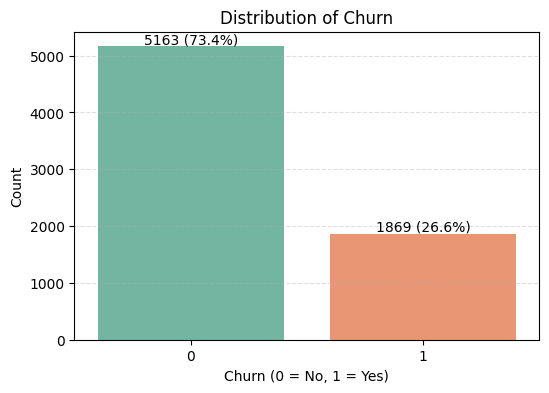

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churn,
    x='Churn',
    hue='Churn',
    palette='Set2',
    legend=False
)

# Calculate counts and percentages
counts = churn['Churn'].value_counts().sort_index()
percentages = churn['Churn'].value_counts(normalize=True).sort_index() * 100

# Add labels: "count (xx.x%)"
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(i, count + 50, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.title('Distribution of Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### •  Most customers do not churn (about 74%), showing a clear class imbalance in the dataset.

### Gender and Churn


In [14]:
churn.groupby('gender').agg({'Churn': ['count', 'sum', 'mean']})

Churn               
       count  sum      mean
gender                     
Female  3483  939  0.269595
Male    3549  930  0.262046

#### Churn is similar for both genders


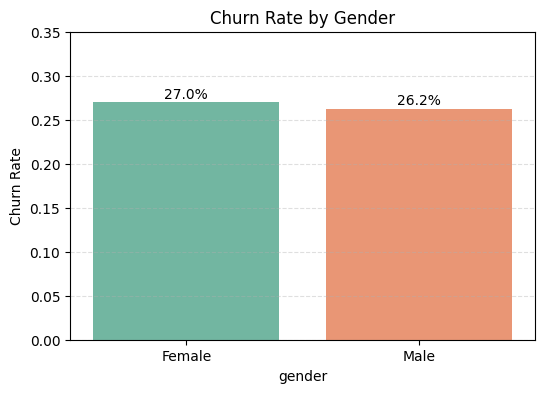

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=churn,
    x='gender',
    y='Churn',
    hue='gender',
    palette='Set2',
    errorbar=None,
    legend=False
)

# Add data labels (percentages)
gender_rates = churn.groupby('gender')['Churn'].mean()

for i, v in enumerate(gender_rates):
    plt.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontsize=10)

plt.ylim(0, 0.35)  # fixes the proportions
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()



### •  Churn rates for male and female customers are nearly identical, indicating that gender does not meaningfully affect churn




## Tenure Distribution


### Tenure Summary
#### Tenure represents how long a customer has been with the company, and it often has a strong relationship with churn behavior

In [16]:
churn['tenure'].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

#### customers stay anywhere from 1 to 72 months, with many leaving early (25% under 9 months) and many staying for years. The wide spread suggests two distinct groups: short‑term customers and long‑term loyal ones

### Tenure Histogram

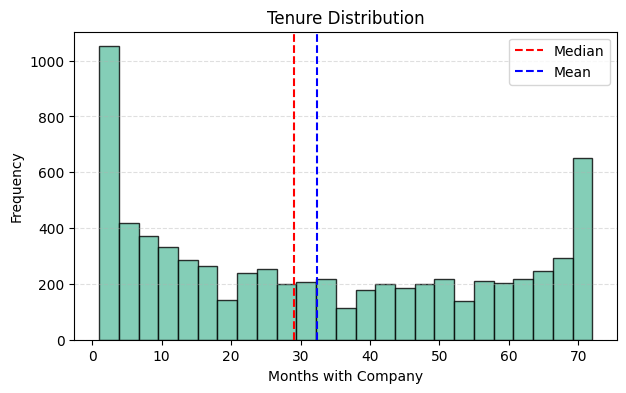

In [17]:
plt.figure(figsize=(7,4))
plt.hist(churn['tenure'], bins=25, edgecolor='black', alpha=0.8, color='#66c2a5')

plt.axvline(churn['tenure'].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
plt.axvline(churn['tenure'].mean(), color='blue', linestyle='--', linewidth=1.5, label='Mean')

plt.title('Tenure Distribution')
plt.xlabel('Months with Company')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

- The tenure distribution is bimodal, with many customers in the very early months and many at the maximum tenure.
- Mid‑range tenures are much less common, creating a clear concentration at both ends of the tenure spectrum.
- The peaks reflect a large inflow of new customers and a substantial group of long‑standing customers.





<hr style="margin-top:30px; margin-bottom:30px;">


### To better understand how tenure relates to churn, we now compare tenure directly between churned and non‑churned customers.
### While the distribution shows overall patterns, these targeted comparisons reveal how strongly tenure separates the two groups and help determine whether this feature should be kept, transformed, or grouped for modeling

## Average Tenure Comparison

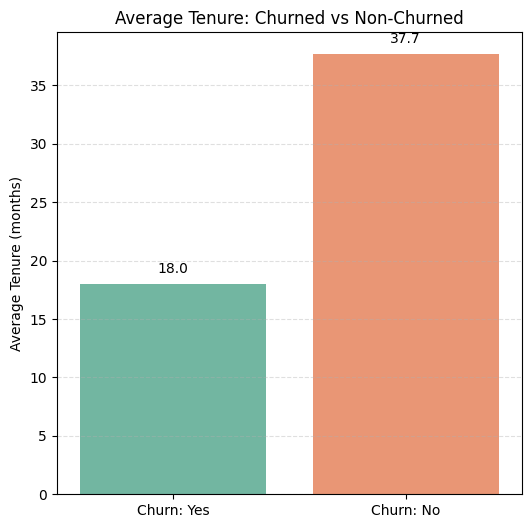

In [18]:
# Calculate average tenure for churned vs non-churned customers
avg_tenure_churn_yes = churn[churn['Churn'] == 1]['tenure'].mean()
avg_tenure_churn_no  = churn[churn['Churn'] == 0]['tenure'].mean()

plt.figure(figsize=(6,6))

# Barplot with proper palette usage
sns.barplot(
    x=['Churn: Yes', 'Churn: No'],
    y=[avg_tenure_churn_yes, avg_tenure_churn_no],
    hue=['Churn: Yes', 'Churn: No'],   # fixes the warning
    palette='Set2',
    legend=False
)

# Add value labels
for i, v in enumerate([avg_tenure_churn_yes, avg_tenure_churn_no]):
    plt.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=10)

plt.title('Average Tenure: Churned vs Non-Churned')
plt.ylabel('Average Tenure (months)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### • 	Non‑churned customers have a much higher average tenure, showing they tend to stay far longer.
### • 	Churned customers show a much lower average, reinforcing that churn happens early in the lifecycle.
### • 	The large gap between the two groups highlights tenure as a strong indicator of churn risk.

### Tenure by Churn

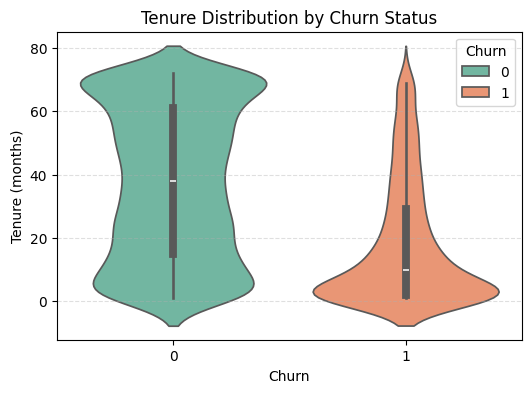

In [19]:
plt.figure(figsize=(6,4))
sns.violinplot(data=churn, x='Churn', y='tenure', palette='Set2',hue='Churn')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### • Short‑tenure churners form a dense cluster at very low tenure values, showing that churn is heavily concentrated in the early months.
### • Non‑churned customers display a much wider and longer distribution, reflecting greater stability once they remain past the initial risk window.
### • The clear separation in distribution shapes highlights tenure as a strong driver of churn, especially during the first year

### Churn Rate by Tenure 

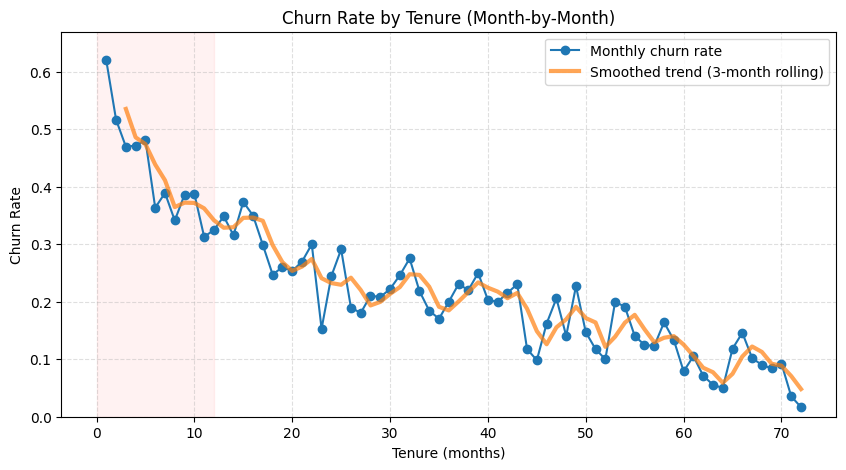

In [20]:
# Month-by-month churn rate
tenure_churn_rate = churn.groupby('tenure')['Churn'].mean()

plt.figure(figsize=(10,5))

# Main line with markers
plt.plot(tenure_churn_rate, marker='o', linewidth=1.5, label='Monthly churn rate')

# Smoothed trend line (3-month rolling average)
plt.plot(tenure_churn_rate.rolling(3).mean(), 
         linewidth=3, alpha=0.7, label='Smoothed trend (3-month rolling)')

# Highlight the first-year "risk zone"
plt.axvspan(0, 12, color='red', alpha=0.05)

plt.title('Churn Rate by Tenure (Month-by-Month)')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate')
plt.grid(True, linestyle='--', alpha=0.4)
plt.ylim(0, tenure_churn_rate.max() + 0.05)
plt.legend()
plt.show()

#### • 	Churn rate is very high in the first few months, then drops sharply.
#### • 	After about 12 months, churn stabilizes at a much lower level.
#### • 	The red-shaded “risk zone” (0–12 months) highlights the critical period where churn is most likely.



<hr style="margin-top:30px; margin-bottom:30px;">


## Tenure Groups

### Tenure is originally a numeric variable, so we group it into meaningful categories to make churn patterns easier to interpret and to enable categorical association tests such as cross‑tabulations and Cramer’s V.

#### Creating Tenure Groups

##### •  0–5 months: Very new customers who are still trying the service and have the highest churn risk.
##### •  6–11 months: Early customers who passed the first months but haven’t reached a full year yet.
##### •  12–23 months: Customers who stayed at least a year and are generally more stable.
##### •  24–47 months: Mid‑term customers who have been with the company for 2–4 years and tend to be loyal.
##### •  48+ months: Long‑term customers who rarely churn and represent the most loyal segment.


In [21]:
churn['TenureGroup'] = '48+ months'
churn.loc[churn['tenure'] < 6, 'TenureGroup'] = '0-5 months'
churn.loc[(churn['tenure'] >= 6) & (churn['tenure'] < 12), 'TenureGroup'] = '6-11 months'
churn.loc[(churn['tenure'] >= 12) & (churn['tenure'] < 24), 'TenureGroup'] = '12-23 months'
churn.loc[(churn['tenure'] >= 24) & (churn['tenure'] < 48), 'TenureGroup'] = '24-47 months'

order = [
    '0-5 months',
    '6-11 months',
    '12-23 months',
    '24-47 months',
    '48+ months'
]

churn['TenureGroup'] = pd.Categorical(
    churn['TenureGroup'],
    categories=order,
    ordered=True
)

churn.groupby('TenureGroup').agg({'Churn': ['count','sum','mean']})

Churn               
             count  sum      mean
TenureGroup                      
0-5 months    1360  744  0.547059
6-11 months    698  255  0.365330
12-23 months  1047  309  0.295129
24-47 months  1624  339  0.208744
48+ months    2303  222  0.096396

In [22]:
churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-5 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-47 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-5 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-47 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-5 months


### Churn Rate by Tenure Group

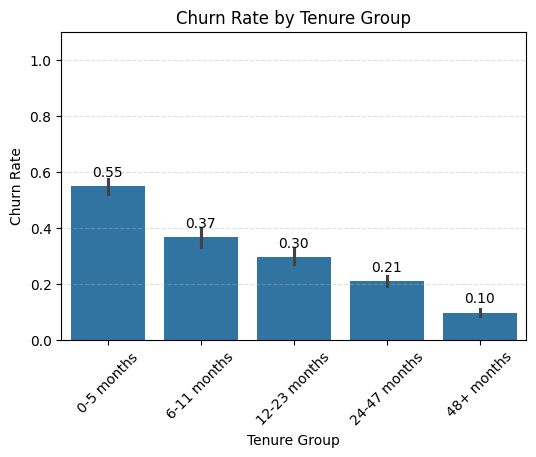

In [23]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='TenureGroup', y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, churn['Churn'].max() + 0.1)
plt.show()



### Short‑tenure customers (0–5 and 6–11 months) have the highest churn rates, while customers with 24+ months of tenure churn far less often. 
### This pattern reinforces that early‑stage customers are the most vulnerable, and long‑term customers tend to be more loyal.


<hr style="margin-top:30px; margin-bottom:30px;">




### To see whether pricing influences churn, we compare MonthlyCharges between churned and non‑churned customers to check if higher monthly fees are linked to higher churn.


## Monthly Charges Groups


### We group MonthlyCharges into broader categories to simplify the relationship between pricing levels and churn and make the feature easier to use in modeling

### Creating the ChargeGroups

##### • 	Low: Customers paying below the 25th percentile; usually basic plans or minimal services.
##### • 	Medium: Customers paying between the 25th and 75th percentiles; the majority of the customer base.
##### • 	High: Customers paying above the 75th percentile; often heavy users or customers with many add‑on services.

In [24]:
q1 = churn['MonthlyCharges'].quantile(0.25)
q3 = churn['MonthlyCharges'].quantile(0.75)

churn['ChargeGroup'] = 'Medium'
churn.loc[churn['MonthlyCharges'] < q1, 'ChargeGroup'] = 'Low'
churn.loc[churn['MonthlyCharges'] > q3, 'ChargeGroup'] = 'High'

churn.groupby('ChargeGroup').agg({'Churn': ['count','sum','mean']})

Churn                
            count   sum      mean
ChargeGroup                      
High         1758   578  0.328783
Low          1758   199  0.113197
Medium       3516  1092  0.310580

#### Higher monthly charges are associated with higher churn.

### Churn rate by ChargeGroup

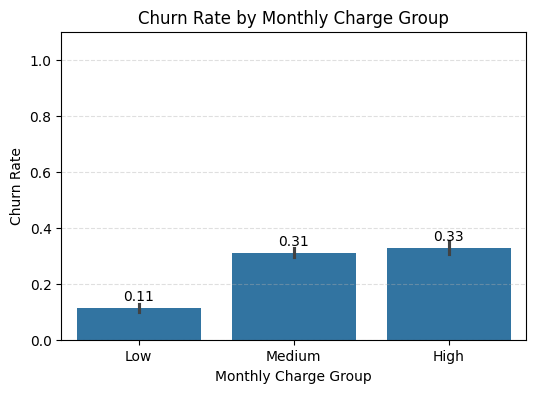

In [25]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='ChargeGroup', y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Churn Rate by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, churn['Churn'].max() + 0.1)
plt.show()

### • 	High‑charge customers churn the most because they pay more, often use more services, and are more sensitive to price increases or service issues.
### • 	Medium‑charge customers churn at nearly the same rate, which suggests that once customers cross a certain price threshold, churn risk rises sharply.
### • 	Low‑charge customers churn the least, which fits with lower bills, simpler service bundles, and often longer tenure.



<hr style="margin-top:30px; margin-bottom:30px;">





### Since TotalCharges reflects each customer’s lifetime value, we compare it between churned and non‑churned customers to understand whether low or high value customers are more likely to leave.

## Total Charges Groups

### We group TotalCharges into value tiers to capture differences between low, mid, and high value customers and to use this information more effectively in churn prediction.

### Creating the TotalCharges groups

In [26]:
q1 = churn['TotalCharges'].quantile(0.25)
q3 = churn['TotalCharges'].quantile(0.75)

churn['TotalChargeGroup'] = 'Mid Value'
churn.loc[churn['TotalCharges'] < q1, 'TotalChargeGroup'] = 'Low Value'
churn.loc[churn['TotalCharges'] > q3, 'TotalChargeGroup'] = 'High Value'

churn.groupby('TotalChargeGroup').agg({'Churn': ['count','sum','mean']})

Churn               
                 count  sum      mean
TotalChargeGroup                     
High Value        1758  255  0.145051
Low Value         1758  764  0.434585
Mid Value         3516  850  0.241752

#### High value customers churn the least while low value customers churn the most.

### Churn rate by TotalChargeGroup

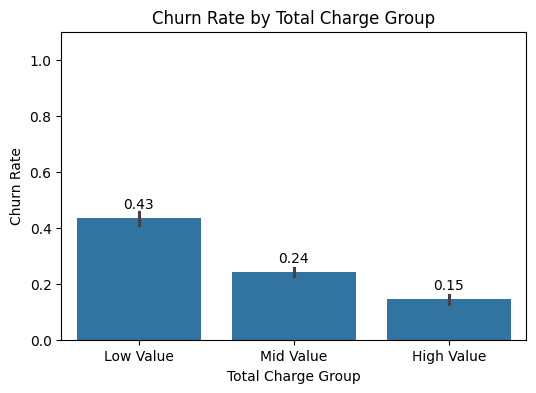

In [27]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='TotalChargeGroup', y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Total Charge Group')
plt.xlabel('Total Charge Group')
plt.ylabel('Churn Rate')
plt.ylim(0, churn['Churn'].max() + 0.1)
plt.show()

#### Low‑value customers churn the most, reflecting that newer or low‑spending customers are more likely to leave.
#### High‑value customers churn the least, showing that long‑term or high‑spending customers tend to be more loyal



<hr style="margin-top:30px; margin-bottom:30px;">




## Contract and Churn

### Contract type strongly influences churn behavior, so we compare churn rates across contract lengths to see how commitment level affects customer retention

#### Churn rate by Contract type

In [28]:
churn.groupby('Contract')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
Contract,,,
Month-to-month,3875,1655,0.427097
One year,1472,166,0.112772
Two year,1685,48,0.028487


##### Month‑to‑month customers churn far more than those on longer contracts.

### Contract vs Churn

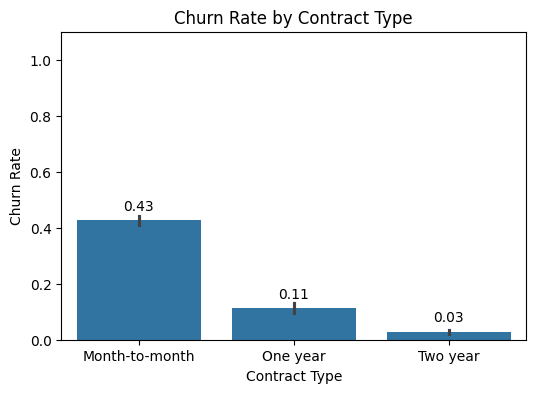

In [29]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='Contract', y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.ylim(0, churn['Churn'].max() + 0.1)
plt.show()

#### • 	Month‑to‑month customers churn at the highest rate, often more than double the churn rate of customers on longer contracts.
#### • 	One‑year contracts show significantly lower churn, indicating increased customer commitment.
#### • 	Two‑year contracts have the lowest churn, suggesting that longer-term agreements strongly reduce the likelihood of leaving

### Pie chart comparison

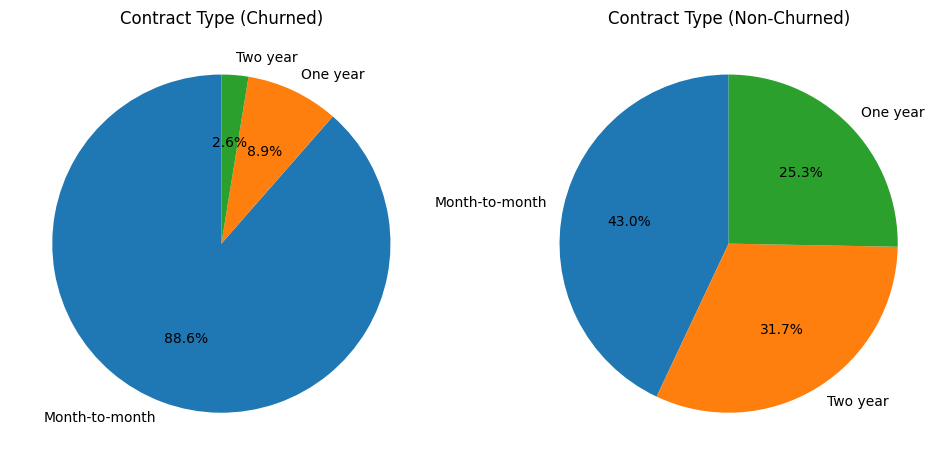

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

churned = churn[churn['Churn']==1]['Contract'].value_counts()
not_churned = churn[churn['Churn']==0]['Contract'].value_counts()

ax1.pie(churned, labels=churned.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Contract Type (Churned)')

ax2.pie(not_churned, labels=not_churned.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Contract Type (Non-Churned)')

plt.show()

### churned customers are overwhelmingly month‑to‑month, while non‑churned customers are more evenly distributed across contract types.

### we can also conclude that month to month contract is preffered amongst customers. 

# Internet Services

---



### Internet Service and Churn

#### Internet service type can influence churn because different technologies offer different speeds, reliability, and pricing.
#### Comparing churn rates across service types  helps reveal whether certain internet plans are associated with higher customer loss.

In [31]:
churn.groupby('InternetService')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
InternetService,,,
DSL,2416,459,0.189983
Fiber optic,3096,1297,0.418928
No,1520,113,0.074342


##### Fiber‑optic customers churn at the highest rate.

### InternetService vs Churn

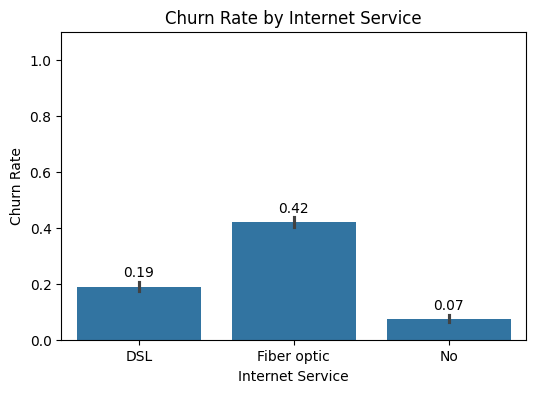

In [32]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='InternetService', y='Churn')


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.xlabel('Internet Service')
plt.ylim(0, churn['Churn'].max() + 0.1)  
plt.show()

#### • 	Fiber optic customers churn at the highest rate, likely due to higher prices or service expectations.
#### • 	DSL customers churn less, suggesting more stable satisfaction or lower pricing.
#### • 	Customers with no internet service churn the least, which makes sense because they typically have fewer services and lower bills.

#### Pie chart comparison

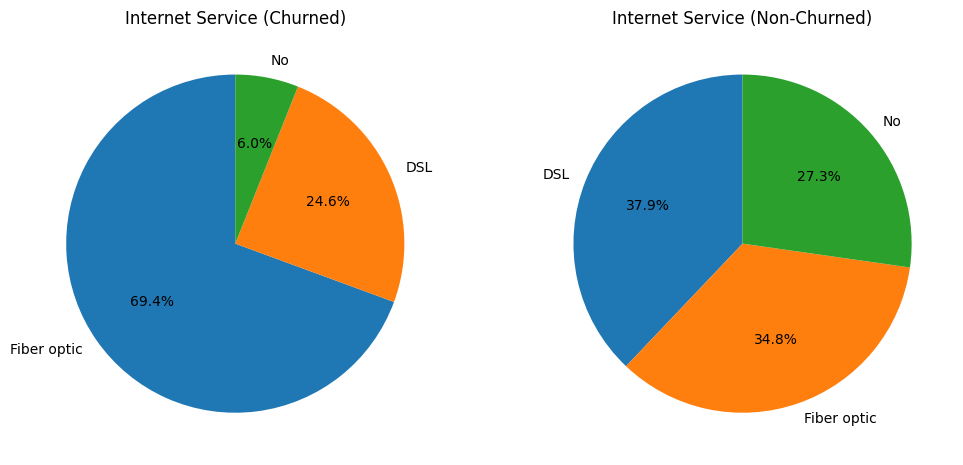

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

churned = churn[churn['Churn']==1]['InternetService'].value_counts()
not_churned = churn[churn['Churn']==0]['InternetService'].value_counts()

ax1.pie(churned, labels=churned.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Internet Service (Churned)')

ax2.pie(not_churned, labels=not_churned.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Internet Service (Non-Churned)')

plt.show()

### churned customers are heavily concentrated in the Fiber optic category, while non‑churned customers are more evenly distributed.




<hr style="margin-top:30px; margin-bottom:30px;">



## Online Security and Churn

### Online security is a key service feature that can influence customer satisfaction. Comparing churn rates across security options helps reveal whether customers without protection are more likely to leave.

#### Churn rate by OnlineSecurity

In [34]:
churn.groupby('OnlineSecurity')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
OnlineSecurity,,,
No,3497,1461,0.417787
No internet service,1520,113,0.074342
Yes,2015,295,0.146402


##### Customers without online security churn far more than those who have it.

### OnlineSecurity vs Churn

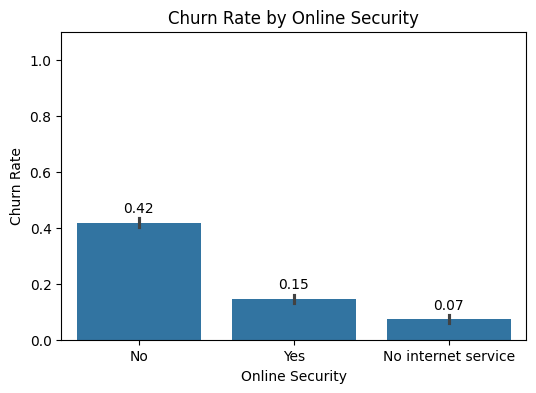

In [35]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='OnlineSecurity', y='Churn')

# Add labels with vertical offset
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Online Security')
plt.ylabel('Churn Rate')
plt.xlabel('Online Security')
plt.ylim(0, churn['Churn'].max() + 0.1)  # extra space for labels
plt.show()

### • Customers without online security churn at the highest rate, suggesting that lack of protection may be associated with    dissatisfaction or higher perceived risk.
### • Customers with online security churn significantly less, indicating that added protection may improve retention.
### • “No internet service” customers show the lowest churn, which is consistent across other service features.


#### Pie chart comparison

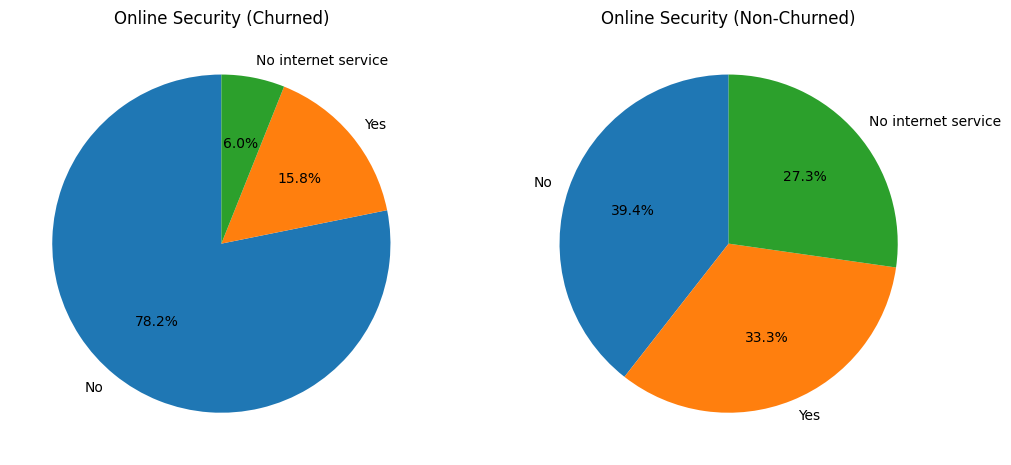

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

churned = churn[churn['Churn']==1]['OnlineSecurity'].value_counts()
not_churned = churn[churn['Churn']==0]['OnlineSecurity'].value_counts()

ax1.pie(churned, labels=churned.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Online Security (Churned)')

ax2.pie(not_churned, labels=not_churned.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Online Security (Non-Churned)')

plt.show()

### churned customers are heavily concentrated in the No category, while non‑churned customers are more evenly distributed.

### We also observe that most customers in general do not opt for the online security add-on.


<hr style="margin-top:30px; margin-bottom:30px;">

## Tech Support and Churn
### Tech support availability can influence customer satisfaction, especially for customers with internet issues.
### Comparing churn rates across support options helps show whether lack of assistance contributes to customer loss.


#### Churn rate by TechSupport

In [37]:
churn.groupby('TechSupport')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
TechSupport,,,
No,3472,1446,0.416475
No internet service,1520,113,0.074342
Yes,2040,310,0.151961


##### Customers without tech support churn at the highest rate.

### TechSupport vs Churn

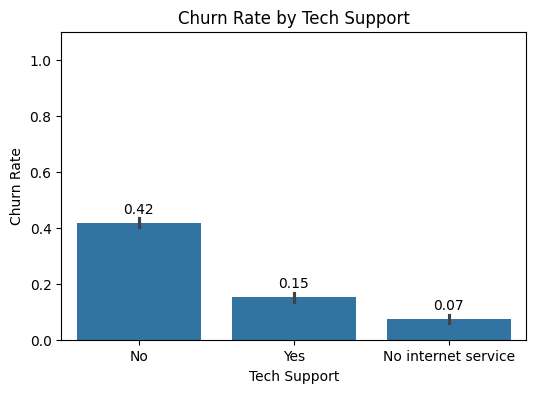

In [38]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='TechSupport', y='Churn')


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Tech Support')
plt.ylabel('Churn Rate')
plt.xlabel('Tech Support')
plt.ylim(0, churn['Churn'].max() + 0.1) 
plt.show()

### • 	Customers without tech support churn at the highest rate, similar to the pattern seen with OnlineSecurity.
### • 	Customers with tech support churn significantly less, suggesting that access to help reduces frustration and improves retention.
### • 	Customers with no internet service show the lowest churn, which is consistent across all internet‑related features.

#### Pie chart comparison

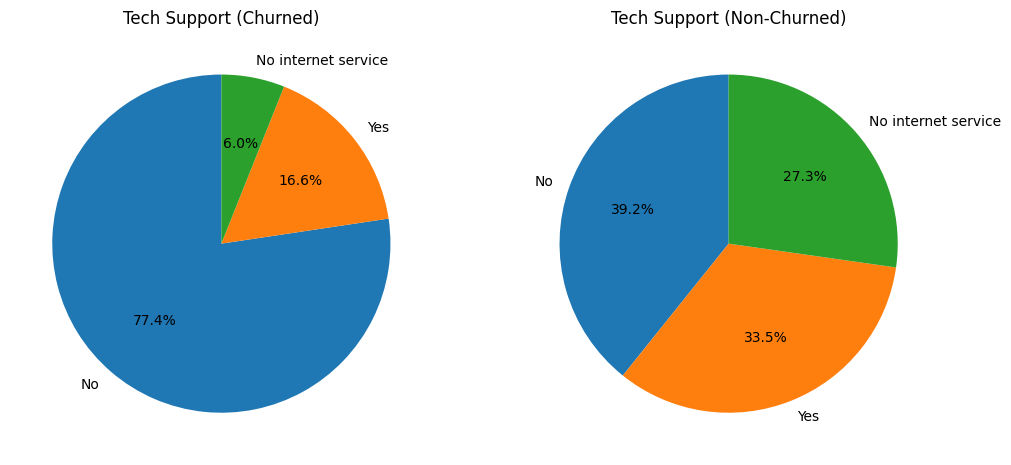

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

churned = churn[churn['Churn']==1]['TechSupport'].value_counts()
not_churned = churn[churn['Churn']==0]['TechSupport'].value_counts()

ax1.pie(churned, labels=churned.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Tech Support (Churned)')

ax2.pie(not_churned, labels=not_churned.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Tech Support (Non-Churned)')

plt.show()

#### churned customers are heavily concentrated in the No category, while non‑churned customers are more evenly distributed.

####  we also observe that most customers in general do not opt for the Tech support add-on.

<hr style="margin-top:30px; margin-bottom:30px;">

## Online Backup and Churn

### Online backup is another optional add‑on service. Comparing churn rates across its categories helps show whether customers without backup services behave differently from those who subscribe to them.

#### OnlineBackup vs Churn

In [40]:
churn.groupby('OnlineBackup')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
OnlineBackup,,,
No,3087,1233,0.399417
No internet service,1520,113,0.074342
Yes,2425,523,0.215670


##### Customers without online backup churn at a much higher rate.

### OnlineBackup vs Churn

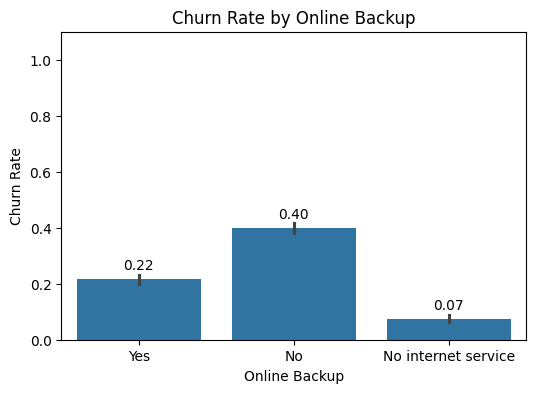

In [41]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x='OnlineBackup', y='Churn')


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Churn Rate by Online Backup')
plt.ylabel('Churn Rate')
plt.xlabel('Online Backup')
plt.ylim(0, churn['Churn'].max() + 0.1)  
plt.show()

### • 	Customers without online backup tend to show higher churn, though the effect is usually weaker than OnlineSecurity or TechSupport.
### • 	Customers with online backup churn less, but the difference is not as strong or consistent.
### • 	Customers with no internet service again show the lowest churn, which matches the pattern across all internet‑related features.

<hr style="margin-top:30px; margin-bottom:30px;">

## Device Protection and Churn

### Device protection is another optional add‑on service. Comparing churn rates across its categories, helps show whether customers who lack protection behave differently from those who subscribe to it.

### Churn rate by DeviceProtection

In [42]:
churn.groupby('DeviceProtection')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
DeviceProtection,,,
No,3094,1211,0.391403
No internet service,1520,113,0.074342
Yes,2418,545,0.225393


##### Customers without device protection churn at a much higher rate.

### DeviceProtection vs Churn

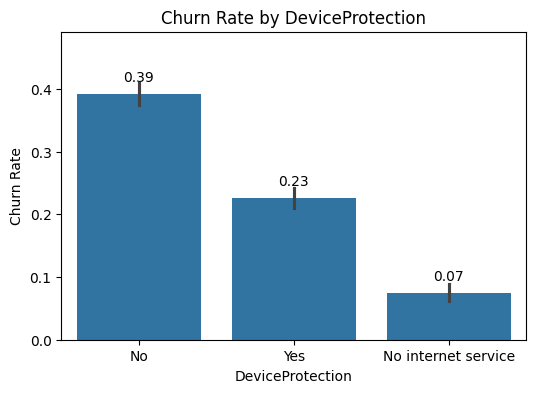

In [43]:
feature = 'DeviceProtection'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=7)


max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Customers without device protection tend to show higher churn, though the effect is usually moderate.
### • 	Customers with device protection churn less, but the difference is not as strong as OnlineSecurity or TechSupport.
### • 	Customers with no internet service again show the lowest churn, consistent with all internet‑related features.

<hr style="margin-top:30px; margin-bottom:30px;">

## Streaming TV and Churn

### Streaming TV is an entertainment add‑on that depends on internet service. Comparing churn rates across its categories helps show whether customers with or without streaming services behave differently

### Churn rate by StreamingTV

In [44]:
churn.groupby('StreamingTV')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
StreamingTV,,,
No,2809,942,0.335351
No internet service,1520,113,0.074342
Yes,2703,814,0.301147


##### Customers without Streaming TV churn slightly more than those who have it.

### StreamingTV vs Churn

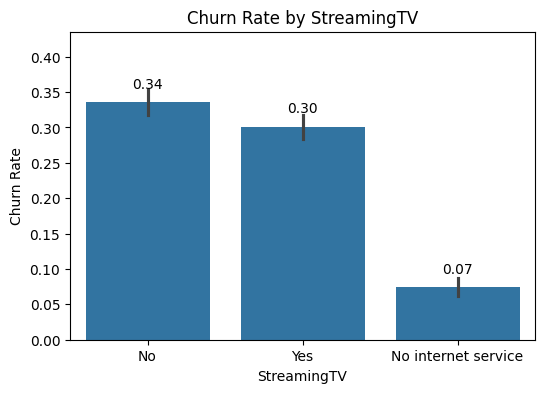

In [45]:
feature = 'StreamingTV'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=8)


max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Customers with StreamingTV = Yes and StreamingTV = No, often show very similar churn rates, meaning this feature is usually a weak predictor on its own.
### • 	Customers with No internet service again show the lowest churn, consistent with all internet‑dependent features.
### • 	The lack of a strong difference suggests that StreamingTV does not significantly influence churn by itself.


<hr style="margin-top:30px; margin-bottom:30px;">

## Streaming Movies and Churn

### StreamingMovies is part of the entertainment bundle available to internet users. Examining churn rates for each category helps determine whether this feature influences customer decisions to stay or leave

### Churn rate by StreamingMovies

In [46]:
churn.groupby('StreamingMovies')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
StreamingMovies,,,
No,2781,938,0.337289
No internet service,1520,113,0.074342
Yes,2731,818,0.299524


##### Customers without Streaming Movies show a somewhat higher churn rate.

### StreamingMovies vs Churn

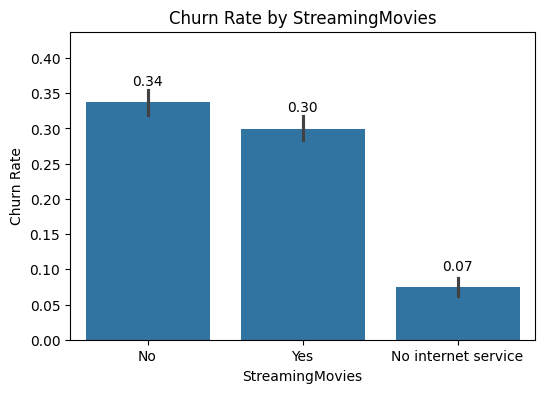

In [47]:
feature = 'StreamingMovies'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Churn levels for Yes and No are almost identical, which shows that StreamingMovies has little standalone influence on whether customers stay or leave.
### • 	The No internet service group continues to show the lowest churn, matching the pattern seen across all internet‑dependent features.
### • 	The small differences across categories indicate that StreamingMovies is not a strong predictor of churn on its own.




# Phone & Lines
---

### PhoneService and Churn

### PhoneService indicates whether the customer has a phone line through the provider. Examining churn rates across its categories helps show whether this basic service has any relationship with customer retention.

### Churn rate by PhoneService

In [48]:
churn.groupby('PhoneService')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
PhoneService,,,
No,680,170,0.250000
Yes,6352,1699,0.267475


##### Phone service shows almost no meaningful difference in churn

### PhoneService vs Churn

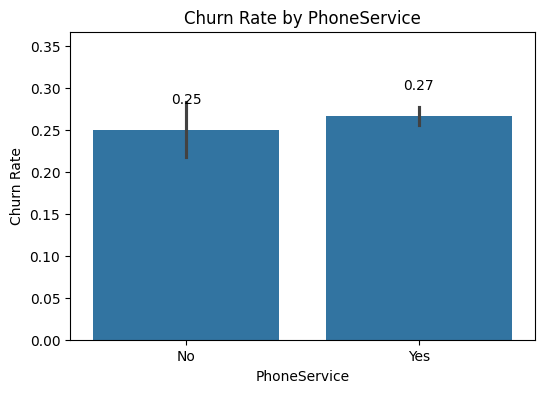

In [49]:
feature = 'PhoneService'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=17)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Churn rates for Yes and No are very similar, showing that PhoneService has little influence on churn by itself.
### • 	This makes sense because most customers have phone service, so the feature doesn’t create strong differences between groups.
### • 	Overall, PhoneService is a weak predictor, but it remains part of the dataset for completeness and potential interactions.

### MultipleLines and Churn

### MultipleLines indicates whether a customer has more than one phone line. Looking at churn across its categories helps show whether having additional lines relates to customer retention.

### Churn rate by MultipleLines

In [50]:
churn.groupby('MultipleLines')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
MultipleLines,,,
No,3385,849,0.250812
No phone service,680,170,0.250000
Yes,2967,850,0.286485


##### Customers with multiple lines churn slightly more than those without them.

### MultipleLines vs Churn

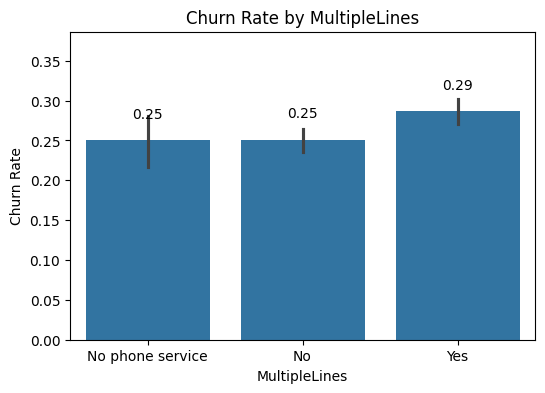

In [51]:
feature = 'MultipleLines'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=14)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	The No phone service and No categories both have a churn rate of 0.25, showing that customers without multiple lines churn at essentially the same rate regardless of whether they have phone service at all.
### • 	Customers with MultipleLines = Yes show a slightly higher churn rate (around 0.29), but the difference is small and not strong enough to make this feature a meaningful predictor on its own.
### • 	Overall, the variation across categories is minimal, which places MultipleLines among the weaker churn predictors in the dataset.

## Customer Demographics

---

### SeniorCitizen and Churn

### SeniorCitizen indicates whether the customer is 65 or older. Comparing churn rates across its categories helps show whether age is associated with different retention patterns.

#### Churn rate by SeniorCitizen

In [52]:
churn.groupby('SeniorCitizen')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
SeniorCitizen,,,
0,5890,1393,0.236503
1,1142,476,0.416813


##### Senior citizens churn at a much higher rate than non‑senior customers.

### SeniorCitizen vs Churn

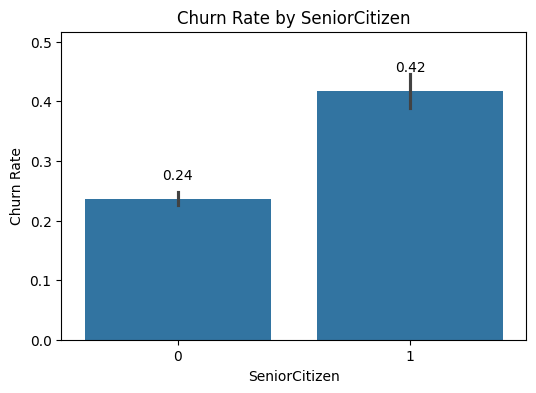

In [53]:
feature = 'SeniorCitizen'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=12)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Customers marked as SeniorCitizen = 1 churn at a much higher rate than younger customers, with a gap of roughly 18 percentage points.
### • 	This makes SeniorCitizen a strong demographic predictor of churn, not a moderate one.
### • 	The pattern may reflect differences in service needs, pricing sensitivity, or comfort with technology among older customers, but the key takeaway is the size of the churn gap.

### Partner and Churn

### Partner indicates whether the customer lives with a partner. Comparing churn rates across its categories helps show whether household structure relates to customer retention.

### Churn rate by Partner

In [54]:
churn.groupby('Partner')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
Partner,,,
No,3639,1200,0.329761
Yes,3393,669,0.197171


##### Living with a partner is associated with noticeably lower churn.

### Partner vs Churn

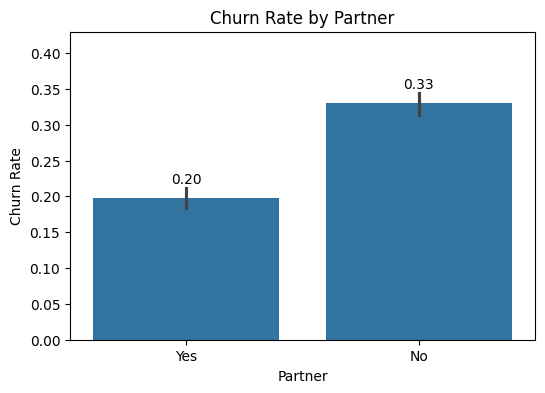

In [55]:
feature = 'Partner'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=9)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Customers with Partner = No churn at a much higher rate than those with a partner.
### • 	The gap is large enough to make Partner a meaningful predictor of churn.
### • 	This suggests that customers living alone may be more likely to switch providers, possibly due to different household needs or lower service bundling.


### Dependents and Churn

### Dependents indicates whether the customer lives with dependents such as children or other family members. Comparing churn rates across its categories helps show whether household responsibilities relate to customer retention.

### Churn rate by Dependents

In [56]:
churn.groupby('Dependents')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
Dependents,,,
No,4933,1543,0.312791
Yes,2099,326,0.155312


##### Churn is significantly higher among customers without dependents

### Dependents vs Churn

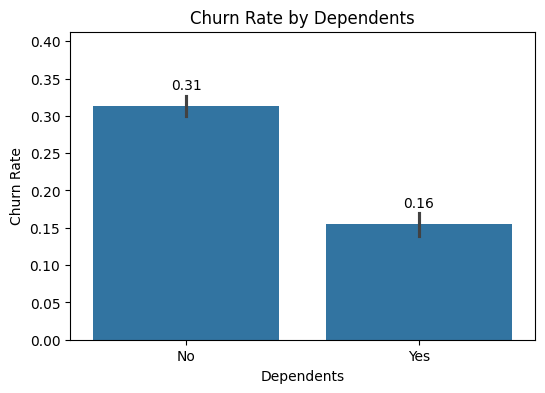

In [57]:
feature = 'Dependents'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

### • 	Customers with no dependents churn at about 0.31, while those with dependents churn at about 0.16, meaning customers without dependents are nearly twice as likely          to leave.
### • 	This makes Dependents a strong demographic predictor of churn, with a clear and meaningful separation between the two groups.

## Billing & Payment

---


### PaperlessBilling and Churn

### PaperlessBilling indicates whether the customer receives bills electronically. Comparing churn across its categories helps show whether billing preferences relate to customer retention.

### Churn rate by PaperlessBilling


In [58]:
churn.groupby('PaperlessBilling')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
PaperlessBilling,,,
No,2864,469,0.163757
Yes,4168,1400,0.335893


##### Paperless‑billing users are noticeably more likely to churn.


### PaperlessBilling vs Churn

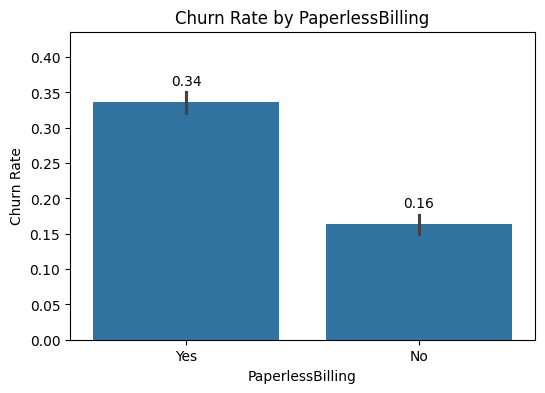

In [59]:
feature = 'PaperlessBilling'

plt.figure(figsize=(6,4))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.show()

#### • 	Customers with PaperlessBilling = Yes churn at about 34%, while those with PaperlessBilling = No churn at about 16%, meaning electronic‑billing customers churn at        more than double the rate of paper‑billing customers.
### • 	This is a strong and meaningful difference, making PaperlessBilling one of the more influential billing‑related predictors of churn.
### • 	The pattern suggests that customers who choose paperless billing may be more price‑sensitive, more digitally active, or more likely to switch providers.

### PaymentMethod and Churn

### PaymentMethod captures how customers pay for their service. Different payment types often show large differences in churn, especially electronic check, which is typically associated with the highest churn rates.

### Churn rate by PaymentMethod

In [60]:
churn.groupby('PaymentMethod')['Churn'].agg(['count','sum','mean'])

,count,sum,mean
PaymentMethod,,,
Bank transfer (automatic),1542,258,0.167315
Credit card (automatic),1521,232,0.152531
Electronic check,2365,1071,0.452854
Mailed check,1604,308,0.192020


##### Electronic‑check users churn far more than customers using any other payment method.

### PaymentMethod vs Churn

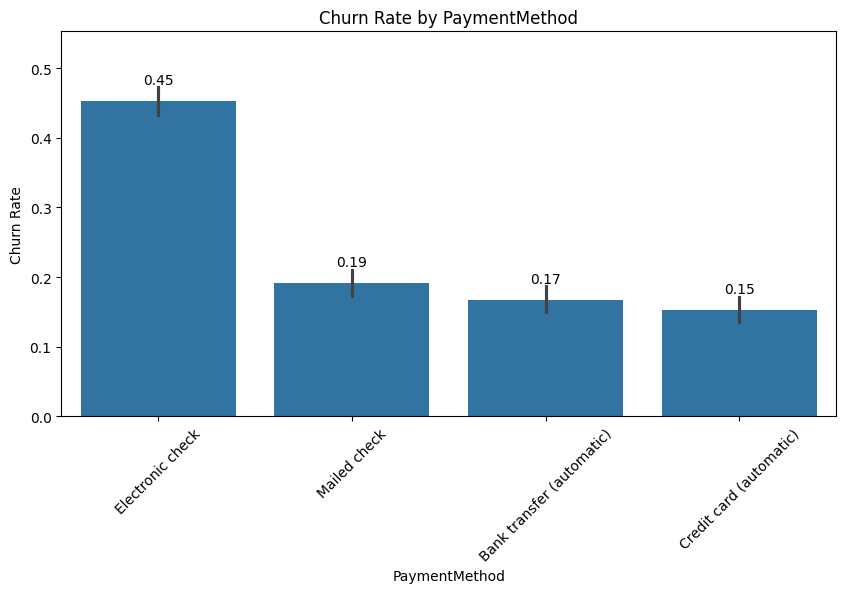

In [61]:
feature = 'PaymentMethod'

plt.figure(figsize=(10,5))
ax = sns.barplot(data=churn, x=feature, y='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)

max_rate = churn.groupby(feature)['Churn'].mean().max()
plt.ylim(0, max_rate + 0.1)

plt.title(f'Churn Rate by {feature}')
plt.ylabel('Churn Rate')
plt.xlabel(feature)
plt.xticks(rotation=45)
plt.show()

### • 	Electronic check customers almost always show the highest churn rate, often dramatically higher than other payment types.
### • 	Credit card, bank transfer, and mailed check customers tend to have much lower churn, forming a clear separation.
### • 	This makes PaymentMethod one of the strongest predictors in the entire dataset, especially because the gap between electronic check and the other methods is typically large.
### • 	The pattern may reflect differences in financial stability, billing reliability, or customer engagement across payment types.

---

# Exploring Relationships Between Features

## Structural Dependencies Between Features

### Several features in the dataset have built‑in logical dependencies. These are not statistical associations but structural rules that determine the values of other features. For example, customers without phone service cannot have multiple lines, and customers without internet service cannot subscribe to any online add‑on services. These dependencies must be recognized before encoding because they will produce perfectly correlated dummy variables

#### quick code to confirm the rule

In [62]:
churn[churn['PhoneService'] == 'No']['MultipleLines'].value_counts()

MultipleLines
No phone service    680
Name: count, dtype: int64

In [63]:
churn[churn['InternetService'] == 'No'][['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].apply(pd.Series.value_counts)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
No internet service,1520,1520,1520,1520,1520,1520


## Statistical Associations Between Categorical Features

#### Beyond structural dependencies, some categorical features show meaningful co‑occurrence patterns.
#### These are statistical associations rather than strict rules, and they help identify overlapping information between features.
#### To explore these relationships, cross‑tabulations and Cramer’s V are used to quantify how strongly two categorical variables are associated.

### Feature pairs analyzed

#### The following pairs are chosen because they commonly show meaningful associations in telecom churn datasets and may influence multicollinearity or model interpretability:

#### • 	Partner and Dependents
#### • 	PaperlessBilling and PaymentMethod
#### • 	Contract and PaperlessBilling
#### • 	Contract and Tenure (binned)
#### • 	InternetService vs ChargeGroup (MonthlyCharges binned)

### Cross‑tabulation

In [64]:
import scipy.stats as ss
import numpy as np

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2/n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Partner vs Dependents
print("Partner vs Dependents")
print(pd.crosstab(churn['Partner'], churn['Dependents'], normalize='index'))
print("Cramer's V:", cramers_v(churn['Partner'], churn['Dependents']))
print("\n")

# PaperlessBilling vs PaymentMethod
print("PaperlessBilling vs PaymentMethod")
print(pd.crosstab(churn['PaperlessBilling'], churn['PaymentMethod'], normalize='index'))
print("Cramer's V:", cramers_v(churn['PaperlessBilling'], churn['PaymentMethod']))
print("\n")

# Contract vs PaperlessBilling
print("Contract vs PaperlessBilling")
print(pd.crosstab(churn['Contract'], churn['PaperlessBilling'], normalize='index'))
print("Cramer's V:", cramers_v(churn['Contract'], churn['PaperlessBilling']))
print("\n")

# Contract vs TenureGroup (after creating bins)
print("Contract vs TenureGroup")
print(pd.crosstab(churn['Contract'], churn['TenureGroup'], normalize='index'))
print("Cramer's V:", cramers_v(churn['Contract'], churn['TenureGroup']))
print("\n")

# InternetService vs ChargeGroup
print("InternetService vs ChargeGroup")
print(pd.crosstab(churn['InternetService'], churn['ChargeGroup'], normalize='index'))
print("Cramer's V:", cramers_v(churn['InternetService'], churn['ChargeGroup']))

Partner vs Dependents
Dependents        No       Yes
Partner                       
No          0.901347  0.098653
Yes         0.487179  0.512821
Cramer's V: 0.45183268563195333


PaperlessBilling vs PaymentMethod
PaymentMethod     Bank transfer (automatic)  Credit card (automatic)  \
PaperlessBilling                                                       
No                                 0.228003                 0.223115   
Yes                                0.213292                 0.211612   

PaymentMethod     Electronic check  Mailed check  
PaperlessBilling                                  
No                        0.217528      0.331355  
Yes                       0.417946      0.157150  
Cramer's V: 0.24681281666494376


Contract vs PaperlessBilling
PaperlessBilling        No       Yes
Contract                            
Month-to-month    0.332645  0.667355
One year          0.457201  0.542799
Two year          0.535312  0.464688
Cramer's V: 0.17569104611066308


Contract vs

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dictionary of your Cramer's V values
cramers_results = {
    "Partner vs Dependents": cramers_v(churn['Partner'], churn['Dependents']),
    "PaperlessBilling vs PaymentMethod": cramers_v(churn['PaperlessBilling'], churn['PaymentMethod']),
    "Contract vs PaperlessBilling": cramers_v(churn['Contract'], churn['PaperlessBilling']),
    "Contract vs TenureGroup": cramers_v(churn['Contract'], churn['TenureGroup']),
    "InternetService vs ChargeGroup": cramers_v(churn['InternetService'], churn['ChargeGroup'])
}

# Convert to DataFrame for heatmap
cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])

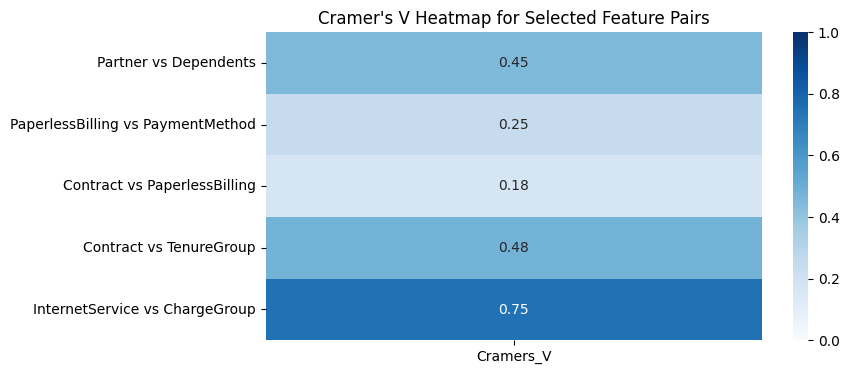

In [116]:
plt.figure(figsize=(8, 4))
sns.heatmap(cramers_df, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Cramer's V Heatmap for Selected Feature Pairs")
plt.show()

### Most feature pairs show weak associations, meaning the categorical variables contribute largely independent information. The only moderate relationship appears between Contract and TenureGroup, which aligns with the expectation that longer contracts correlate with longer customer tenure.

---

### Interpretation of Associations (Cramer’s V)
### • 	Partner vs Dependents : 0.45 (strong)
####     Customers with partners often have dependents, while those without partners usually don’t, showing a clear household‑structure link.
### • 	PaperlessBilling vs PaymentMethod: 0.25 (moderate)
####     Electronic‑check users tend to use paperless billing, while mailed‑check users avoid it. Other payment types are more evenly distributed.
### • 	Contract vs PaperlessBilling: 0.18 (weak)
####     Month‑to‑month customers use paperless billing more often, but overall the relationship is weak and the features remain mostly independent.
### • 	Contract vs TenureGroup: 0.48 (strong)
####     New customers are almost all month‑to‑month, while long‑tenure customers hold long‑term contracts, showing a strong lifecycle pattern.
### • 	InternetService vs ChargeGroup: 0.75 (very strong)
####     Internet service type strongly determines charge level: fiber‑optic is high‑cost, DSL is mid‑range, and no‑internet customers fall into low charges.

---

---
# Data Preprocessing for Modeling
---

### We now prepare the dataset for modeling by encoding categorical variables and analyzing correlations in the encoded data to ensure stable and interpretable models.

### Data Cleaning and Preparation

#### Handling missing values
#### The TotalCharges column originally contained 11 missing values. These belonged to customers with tenure = 0 who had not yet received a bill. Since these values cannot be meaningfully imputed, the rows were removed earlier in the workflow.
#### Interpretation:
#### Removing these rows ensures that TotalCharges is fully numeric and prevents errors during encoding and modeling.

### Removing identifier columns
#### The customerID column is a unique identifier and carries no predictive information. Keeping it would also create thousands of dummy variables during encoding.

In [65]:
churn = churn.drop(columns=['customerID'])

In [66]:
churn.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,TotalChargeGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-5 months,Low,Low Value
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,24-47 months,Medium,Mid Value
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-5 months,Medium,Low Value



### Feature Selection Based on EDA
---

#### Features removed due to no predictive value
#### Exploratory analysis showed that some features have almost identical churn rates across categories, meaning they do not help the model.

In [67]:
# Drop features with no predictive value
churn = churn.drop(columns=['gender', 'PhoneService', 'MultipleLines'])

In [68]:
churn.head(3)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,TotalChargeGroup
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-5 months,Low,Low Value
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-47 months,Medium,Mid Value
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-5 months,Medium,Low Value


### Interpretation:
#### • 	gender shows nearly identical churn rates for male and female.
#### • 	PhoneService is almost universally “Yes,” offering no signal.
#### • 	MultipleLines adds little value once PhoneService is removed and is largely explained by InternetService.
### These features add noise and unnecessary dummy variables, so they are removed before encoding.




### Features kept due to meaningful predictive value:



#### EDA revealed substantial churn differences across the following features, so they are retained:
#### • 	SeniorCitizen- churn nearly doubles for senior customers.
#### • 	Partner- customers without partners churn significantly more.
#### • 	Dependents- customers with dependents churn far less.
#### • 	Tenure- one of the strongest predictors; churn drops sharply with longer tenure.
#### • 	InternetService- fiber customers churn at much higher rates.
#### • 	OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport- strong churn differences between Yes/No.
#### • 	StreamingTV, StreamingMovies- moderate but meaningful differences.
#### • 	Contract- extremely strong predictor; month‑to‑month customers churn far more.
#### • 	PaperlessBilling- customers with paperless billing churn more.
#### • 	PaymentMethod- electronic check customers churn at very high rates.
#### • 	MonthlyCharges, TotalCharges- continuous predictors with clear churn patterns.
#### • 	Churn- target variable.
#### Interpretation:
### These features show clear, meaningful churn differences and are essential for modeling. Removing them would weaken predictive performance.

---
### Encode the categorical variables
---


#### One‑hot encoding

#### Categorical variables are converted into numerical dummy variables. drop_first=True avoids multicollinearity by removing one category per feature.

In [69]:
encoded = pd.get_dummies(churn, drop_first=True)
encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_6-11 months,TenureGroup_12-23 months,TenureGroup_24-47 months,TenureGroup_48+ months,ChargeGroup_Low,ChargeGroup_Medium,TotalChargeGroup_Low Value,TotalChargeGroup_Mid Value
0,0,1,29.85,29.85,0,True,False,False,False,False,...,True,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,0,2,70.70,151.65,1,False,False,True,False,False,...,True,False,False,False,False,False,False,True,True,False


#### The dataset is now fully numeric and ready for correlation analysis. Dropping the first category ensures that no dummy variable is perfectly predicted by others.

----

### Computing the correlation matrix

In [70]:
corr_matrix = encoded.corr()

### Visualizing the correlations

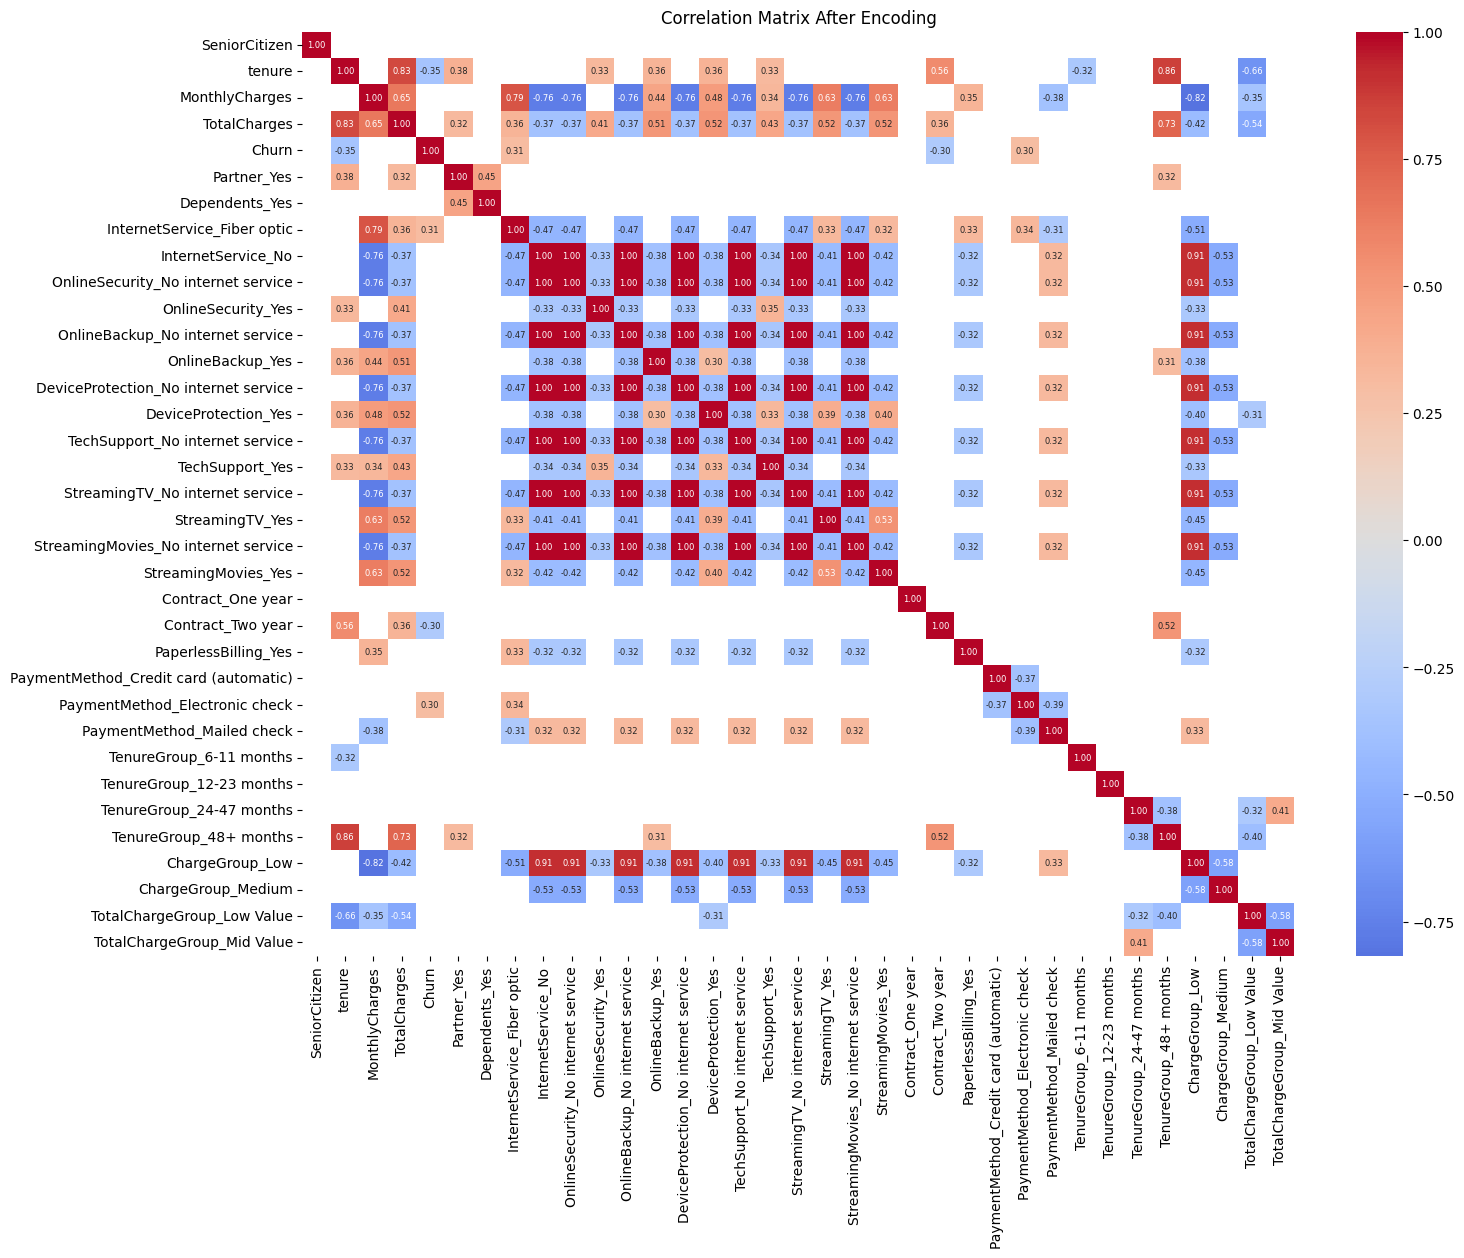

In [71]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f",annot_kws={"size": 6},
    mask=abs(corr_matrix) < 0.3
)
plt.title("Correlation Matrix After Encoding")
plt.show()

In [72]:
corr_matrix['Churn'].sort_values(ascending=False)


Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
TotalChargeGroup_Low Value               0.220615
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
ChargeGroup_Medium                       0.101404
TenureGroup_6-11 months                  0.074805
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
TenureGroup_12-23 months                 0.027783
TotalChargeGroup_Mid Value              -0.054404
DeviceProtection_Yes                    -0.066193
TenureGroup_24-47 months                -0.070760
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128





### Heatmap interpretation
### • 	Fiber optic internet (0.31) shows a positive correlation with churn, meaning customers using fiber are more likely to leave.
### • 	Electronic check payments (0.30) also correlate positively with churn, indicating higher churn among these customers.
### • 	Tenure (–0.35) has the strongest negative correlation with churn, showing that long‑term customers are less likely to leave.
### • 	One‑ and two‑year contracts (–0.18 and –0.30) correlate negatively with churn, meaning contract customers churn less than month‑to‑month customers.
### • 	No‑internet‑service categories (around –0.23) cluster together, reflecting that customers without internet services rarely churn.
### • 	TotalCharges and MonthlyCharges groups (0.19 to –0.20) correlate with their numeric versions, confirming they represent the same spending patterns.


----
# Selected features for modeling
----

## Key predictors to keep:
### These features show the strongest and most meaningful relationships with churn :
#### •   SeniorCitizen
#### • 	Tenure
#### • 	Contract type (One year, Two year)
#### • 	InternetService_Fiber optic
#### • 	PaymentMethod_Electronic check
#### • 	OnlineSecurity_Yes
#### • 	TechSupport_Yes
### These variables capture the main behavioral and service patterns that influence whether a customer stays or leaves.


## Features to remove:
### These variables repeat the same information or add unnecessary complexity:
#### • 	Grouped versions of tenure
#### • 	Grouped versions of charges
#### • 	All “No internet service” categories
### Removing them avoids duplication and reduces multicollinearity, which helps both linear and tree‑based models perform more reliably.

----

### Final Feature Selection

In [73]:
# Final feature set for modeling
selected_features = [
    'tenure',
    'Contract_One year',
    'Contract_Two year',
    'InternetService_Fiber optic',
    'PaymentMethod_Electronic check',
    'OnlineSecurity_Yes',
    'TechSupport_Yes',
    'SeniorCitizen',
    'Partner_Yes',
    'Dependents_Yes'
]


X = encoded[selected_features]
y = encoded['Churn']

In [74]:
X.head(3)

,tenure,Contract_One year,Contract_Two year,InternetService_Fiber optic,PaymentMethod_Electronic check,OnlineSecurity_Yes,TechSupport_Yes,SeniorCitizen,Partner_Yes,Dependents_Yes
0,1,False,False,False,True,False,False,0,True,False
1,34,True,False,False,False,True,False,0,False,False
2,2,False,False,False,False,True,False,0,False,False


In [75]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

---

---

# Classical Machine Learning Models 

To evaluate the predictive performance of different classical machine‑learning methods, this section tests the algorithms required by the project instructions: **K‑Nearest Neighbors (KNN)**, **Decision Tree**, and **Random Forest**. These models provide a baseline for comparison and help illustrate how different learning approaches behave on the churn dataset.


All models are trained using the same preprocessed feature set selected earlier based on correlation analysis and domain understanding. For each algorithm, several hyperparameter values are tested (such as different k values for KNN and different max_depth values for Decision Trees and Random Forests). The goal is to compare their performance on the test set and identify which classical model performs best before moving on to more advanced models such as **Logistic Regression**, **Gradient Boosting**, and **XGBoost**.

---

## KNN - K Nearest Neighbors

To ensure consistent evaluation across all models, the dataset is split into training and testing sets using an 80/20 ratio. Stratification is applied to preserve the churn distribution in both sets, preventing class imbalance from affecting model performance.


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Hyperparameter Search for k

KNN performance depends heavily on the number of neighbors. Multiple k values are tested to identify the optimal balance between underfitting (small k) and overfitting (large k). Each model is trained on the same feature set to ensure a fair comparison.

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9 ,11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results.append([k, acc])

knn_results

[[3, 0.7583511016346838],
 [5, 0.7711442786069652],
 [7, 0.7796730632551528],
 [9, 0.7796730632551528],
 [11, 0.7839374555792467]]

In [78]:
# --- BEST KNN MODEL (k=11) ---
from sklearn.metrics import classification_report

best_k = 11
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train[selected_features], y_train)

pred_knn = knn.predict(X_test[selected_features])

print(f"\nKNN (k={best_k}) Accuracy:", accuracy_score(y_test, pred_knn))
print("\nKNN CLASSIFICATION REPORT")
print(classification_report(y_test, pred_knn))




KNN (k=11) Accuracy: 0.7839374555792467

KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



### KNN Accuracy Results

##### The table below summarizes test accuracy for different k values. Accuracy improves steadily as k increases, stabilizing around k = 9–11, indicating that moderate smoothing yields the best generalization.


## KNN Accuracy Curve

##### This plot visualizes how test accuracy changes as k increases from 1 to 20. Very small k values overfit the training data, while larger k values reduce variance and improve stability.
##### The curve confirms that the optimal region lies around k = 9–11

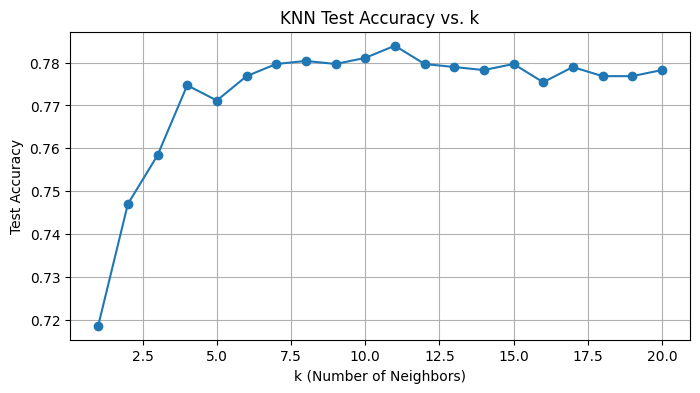

In [79]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8,4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy vs. k")
plt.grid(True)
plt.show()

- Accuracy rises quickly from very small k values, showing that k=1–3 overfits because the model reacts too strongly to noise.
- Accuracy stabilizes around k≈10–12, indicating the model has reached a good balance between noise‑sensitivity and oversmoothing.
- Beyond that point, accuracy fluctuates only slightly, meaning additional neighbors don’t meaningfully improve generalization.
- The curve’s flattening suggests the model has reached its optimal complexity, and further increases in k would mostly add bias without reducing variance.


## Decision Tree 

Used to establish a simple tree‑based baseline before moving on to more robust ensemble methods.

In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depth_values = [2, 3, 5, 7, None]   # None = full depth
dt_results = []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    dt_results.append([d, acc])

dt_results

[[2, 0.7846481876332623],
 [3, 0.7846481876332623],
 [5, 0.7846481876332623],
 [7, 0.7725657427149965],
 [None, 0.7320540156361052]]

In [81]:
# --- BEST DECISION TREE MODEL (max_depth=2) ---
best_depth = 3
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train[selected_features], y_train)

pred_dt = dt.predict(X_test[selected_features])

print(f"\nDecision Tree (max_depth={best_depth}) Accuracy:", accuracy_score(y_test, pred_dt))
print("\nDECISION TREE CLASSIFICATION REPORT")
print(classification_report(y_test, pred_dt))



Decision Tree (max_depth=3) Accuracy: 0.7846481876332623

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



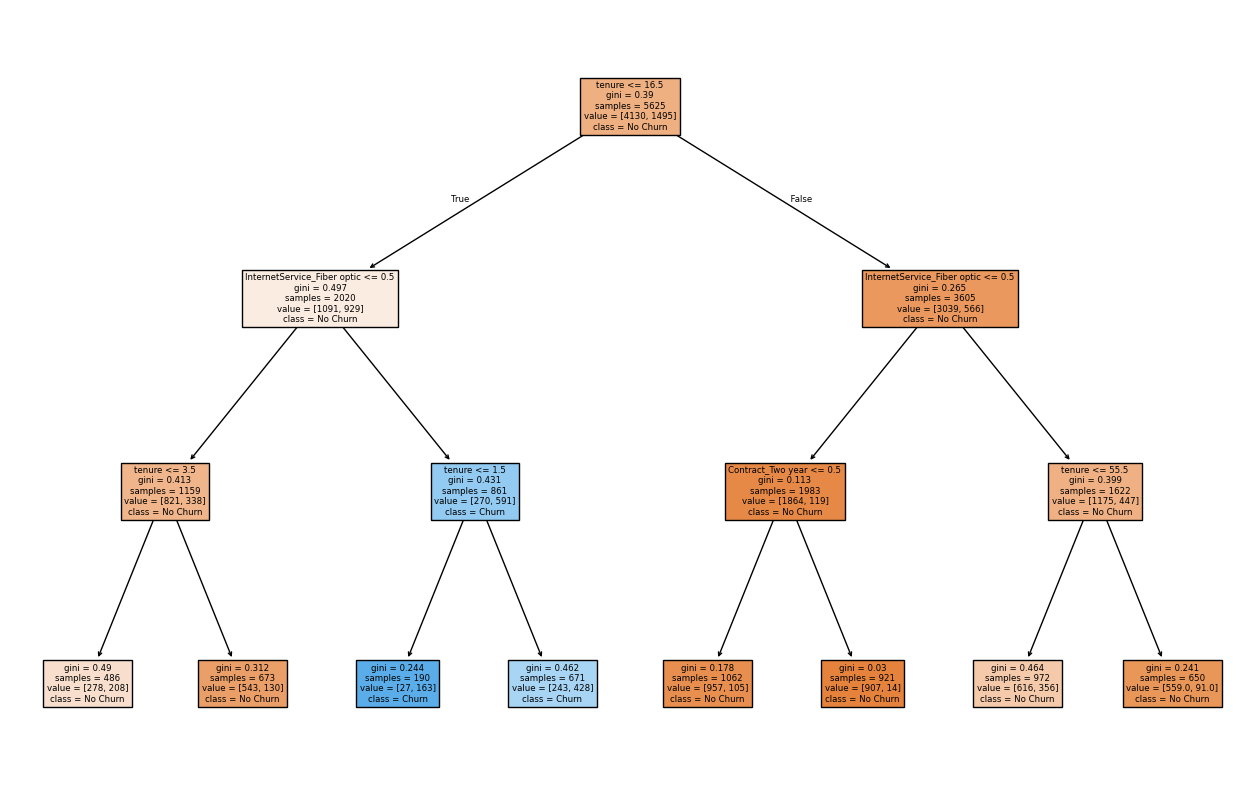

In [82]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
best_dt.fit(X_train, y_train)

plt.figure(figsize=(16,10))
plot_tree(best_dt, filled=True, feature_names=X_train.columns, class_names=["No Churn", "Churn"])
plt.show()

### Decision Tree Interpretation

- **Fiber optic internet** is the strongest churn driver. customers with fiber service split immediately toward **higher churn risk**.
- Very **low tenure** sharply **increases churn**, while **long‑tenure** customers are much **more stable**.
- Contract type reduces churn, especially **two‑year contracts**, which lead to very **low churn rates**.


## Random Forest (Classical Model – Accuracy Focused)

Explores multiple Random Forest hyperparameter combinations to identify the configuration that achieves the highest test accuracy.

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depth_values = [None, 10, 20]
estimator_values = [100, 300, 500]
max_features_values = ["sqrt", "log2"]
min_samples_leaf_values = [1, 2, 4]

rf_results = []

for d in depth_values:
    for n in estimator_values:
        for mf in max_features_values:
            for leaf in min_samples_leaf_values:
                
                rf = RandomForestClassifier(
                    max_depth=d,
                    n_estimators=n,
                    max_features=mf,
                    min_samples_leaf=leaf,
                    random_state=42
                )
                
                rf.fit(X_train, y_train)
                y_pred = rf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                
                rf_results.append([d, n, mf, leaf, acc])

rf_results

[[None, 100, 'sqrt', 1, 0.7405828002842928],
 [None, 100, 'sqrt', 2, 0.7697228144989339],
 [None, 100, 'sqrt', 4, 0.7853589196872779],
 [None, 100, 'log2', 1, 0.7405828002842928],
 [None, 100, 'log2', 2, 0.7697228144989339],
 [None, 100, 'log2', 4, 0.7853589196872779],
 [None, 300, 'sqrt', 1, 0.7427149964463398],
 [None, 300, 'sqrt', 2, 0.7683013503909026],
 [None, 300, 'sqrt', 4, 0.7882018479033405],
 [None, 300, 'log2', 1, 0.7427149964463398],
 [None, 300, 'log2', 2, 0.7683013503909026],
 [None, 300, 'log2', 4, 0.7882018479033405],
 [None, 500, 'sqrt', 1, 0.7434257285003554],
 [None, 500, 'sqrt', 2, 0.7683013503909026],
 [None, 500, 'sqrt', 4, 0.7874911158493249],
 [None, 500, 'log2', 1, 0.7434257285003554],
 [None, 500, 'log2', 2, 0.7683013503909026],
 [None, 500, 'log2', 4, 0.7874911158493249],
 [10, 100, 'sqrt', 1, 0.7810945273631841],
 [10, 100, 'sqrt', 2, 0.7874911158493249],
 [10, 100, 'sqrt', 4, 0.7903340440653873],
 [10, 100, 'log2', 1, 0.7810945273631841],
 [10, 100, 'log2',

## Feature importance plot



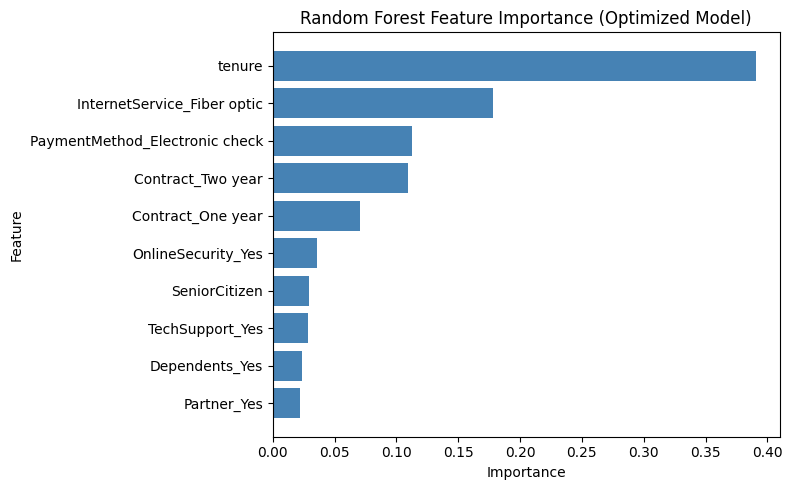

In [84]:
# Train the optimized Random Forest model
best_rf = RandomForestClassifier(
    max_depth=10,
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=4,
    random_state=42
)

best_rf.fit(X_train, y_train)

# Extract feature importances
importances = best_rf.feature_importances_

# Sort features by importance
import numpy as np
sorted_idx = np.argsort(importances)

# Plot
plt.figure(figsize=(8,5))
plt.barh(np.array(selected_features)[sorted_idx], importances[sorted_idx], color="steelblue")
plt.title("Random Forest Feature Importance (Optimized Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### Tenure is the most influential feature, meaning how long a customer has been with the company is the strongest predictor of churn. Short‑tenure customers are far more likely to leave.
#### Fiber‑optic internet and contract type (especially two‑year contracts) are major drivers: fiber‑optic users churn more, while long‑term contracts significantly reduce churn.
#### Electronic check payment method also ranks high, indicating customers who pay this way tend to churn more than those using other payment methods.


## Comparison of all three (train & test)

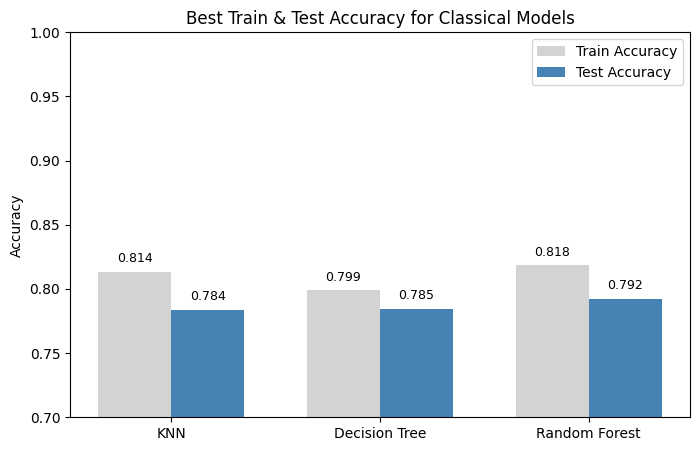

In [85]:
# Best models
best_knn = KNeighborsClassifier(n_neighbors=11)
best_knn.fit(X_train, y_train)
knn_train = accuracy_score(y_train, best_knn.predict(X_train))
knn_test = accuracy_score(y_test, best_knn.predict(X_test))

best_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt.fit(X_train, y_train)
dt_train = accuracy_score(y_train, best_dt.predict(X_train))
dt_test = accuracy_score(y_test, best_dt.predict(X_test))

best_rf = RandomForestClassifier(
    max_depth=10,
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=4,
    random_state=42
)
best_rf.fit(X_train, y_train)
rf_train = accuracy_score(y_train, best_rf.predict(X_train))
rf_test = accuracy_score(y_test, best_rf.predict(X_test))

train_scores = {
    "KNN": knn_train,
    "Decision Tree": dt_train,
    "Random Forest": rf_train
}

test_scores = {
    "KNN": knn_test,
    "Decision Tree": dt_test,
    "Random Forest": rf_test
}

import numpy as np
import matplotlib.pyplot as plt

models = list(train_scores.keys())
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
bars1 = plt.bar(x - width/2, train_scores.values(), width, label="Train Accuracy", color="lightgray")
bars2 = plt.bar(x + width/2, test_scores.values(), width, label="Test Accuracy", color="steelblue")

# Add data labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}",
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Best Train & Test Accuracy for Classical Models")
plt.ylim(0.70, 1.00)
plt.legend()
plt.show()

### Summary of Classical Model Performance
### • 	Random Forest achieves the strongest performance, with the highest test accuracy (~0.792) and a small train–test gap. This shows it captures non‑linear churn patterns effectively while maintaining       good generalization.

### • 	Decision Tree performs slightly below Random Forest (~0.785). It models the main structure of the data but lacks the stability and averaging benefits of an ensemble, making it more sensitive to          overfitting.

### • 	KNN shows the weakest performance (~0.784) and the largest gap between train and test accuracy. Distance‑based methods struggle with mixed categorical–numeric feature spaces and are more affected by     noise, which limits their effectiveness here.






---

## Benchmark Model: Majority‑Class Baseline

In [113]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [114]:
benchmark_value = y_train.value_counts().idxmax()
benchmark_value

np.int64(0)

In [111]:
import numpy as np

def get_benchmark_predictions(x, benchmark_value):
    return np.ones(len(x)) * benchmark_value

y_test_pred_benchmark = get_benchmark_predictions(X_test, benchmark_value)

In [112]:
from sklearn.metrics import accuracy_score

benchmark_test_acc = accuracy_score(y_test, y_test_pred_benchmark)
benchmark_test_acc

0.7341862117981521

## To conclude

#### The majority‑class benchmark reaches **73.4%** accuracy, which is what we’d expect from a model that always predicts “not churn.”

#### All three classical models perform better than this, showing they capture real patterns in the data. The strongest of the group is Random Forest, with a test accuracy of **79.2%**, about six points above the baseline.

#### Still, accuracy doesn’t tell the full story in an imbalanced churn problem. A model can score well overall while missing many actual churners, which is why the next step focuses on more advanced models and improving recall.


# Advanced Models

After evaluating the required classical algorithms (KNN, Decision Tree, and Random Forest), we now move to more advanced models to improve predictive performance and better understand churn behavior.

These include **Logistic Regression**, a **tuned Random Forest**, **Gradient Boosting**, and **XGBoost** with threshold optimization. These models allow deeper analysis of precision–recall tradeoffs and provide more actionable insights for identifying customers at risk of churning.

---

## Logistic Regression 

After evaluating the classical models, Logistic Regression serves as the first step into more advanced predictive modeling.

Although it is still a relatively simple algorithm, it introduces a probabilistic framework that estimates churn likelihood directly.

Unlike tree‑based models, it assumes linear relationships between features and churn probability, which makes it highly interpretable and useful for understanding directional effects.

This model provides a strong baseline before moving on to more flexible non‑linear methods such as Gradient Boosting and XGBoost.

## Model training

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions and accuracy

In [87]:
log_train = accuracy_score(y_train, log_reg.predict(X_train))
log_test = accuracy_score(y_test, log_reg.predict(X_test))

print("Train Accuracy:", log_train)
print("Test Accuracy:", log_test)

Train Accuracy: 0.7955555555555556
Test Accuracy: 0.7931769722814499


## Classification report

In [88]:
print("\nLOGISTIC REGRESSION MODEL")
print(classification_report(y_test, log_reg.predict(X_test)))


LOGISTIC REGRESSION MODEL
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## Coefficients

In [89]:
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
3,InternetService_Fiber optic,1.233771
4,PaymentMethod_Electronic check,0.546887
7,SeniorCitizen,0.304805
8,Partner_Yes,-0.002883
0,tenure,-0.026151
6,TechSupport_Yes,-0.134524
9,Dependents_Yes,-0.291950
5,OnlineSecurity_Yes,-0.292031
1,Contract_One year,-0.837547
2,Contract_Two year,-1.571940



- Logistic Regression performs well as a linear baseline, reaching a test accuracy of ~0.793, which is close to the Random Forest result. 

- The small train–test gap shows that the model generalizes reliably. Its coefficients reveal clear patterns: Fiber optic and Electronic check increase churn likelihood, while longer contracts, tenure, and security‑related services reduce it. 

- These effects align with typical churn behavior and confirm that the selected features carry meaningful linear signal.

### Overall, Logistic Regression provides a solid, interpretable step up from the classical models before moving on to more flexible non‑linear methods.


---

## Random Forest (Advanced Model – Recall Optimized)
Trains a weighted Random Forest to handle class imbalance and improve recall for churners. This version prioritizes identifying at‑risk customers over overall accuracy, offering a more sensitive churn‑detection model than the classical accuracy‑focused version.

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest using the previously defined final_features
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train[selected_features], y_train)

# Predictions
pred_rf = rf.predict(X_test[selected_features])

# Accuracy
rf_train = accuracy_score(y_train, rf.predict(X_train[selected_features]))
rf_test = accuracy_score(y_test, pred_rf)

print("Train Accuracy:", rf_train)
print("Test Accuracy:", rf_test)

# Classification report
print("\nRANDOM FOREST MODEL")
print(classification_report(y_test, pred_rf))

Train Accuracy: 0.7875555555555556
Test Accuracy: 0.7491115849324804

RANDOM FOREST MODEL
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



## Random Forest vs. Logistic Regression: Key Differences

### Random Forest outperforms Logistic Regression for churn detection on this dataset because it captures significantly more true churners (recall 0.78 vs. 0.52). Although Logistic Regression is more accurate overall and more precise, it misses many at‑risk customers.

### For churn prediction, where identifying potential churners is the priority, Random Forest is currently the stronger model.

---



## Moving to Gradient Boosting



Now that Random Forest has been evaluated, the next step is to train a Gradient Boosting model using the finalized feature set. This allows us to test whether a boosting‑based ensemble can provide a more balanced trade‑off between precision, recall, and overall accuracy.

In [91]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Gradient Boosting model using the previously defined final_features
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train[selected_features], y_train)

# Predictions
pred_gb = gb.predict(X_test[selected_features])

# Accuracy
gb_train = accuracy_score(y_train, gb.predict(X_train[selected_features]))
gb_test = accuracy_score(y_test, pred_gb)

print("Train Accuracy:", gb_train)
print("Test Accuracy:", gb_test)

print("\nGRADIENT BOOSTING MODEL")
print(classification_report(y_test, pred_gb))

Train Accuracy: 0.8081777777777778
Test Accuracy: 0.7860696517412935

GRADIENT BOOSTING MODEL
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Gradient Boosting reaches 0.79 accuracy, matching Logistic Regression and outperforming Random Forest.
### However, its churn‑class recall (0.51) is similar to Logistic Regression and much lower than Random Forest. Precision for churners (0.62) is also close to Logistic Regression.
### This means Gradient Boosting behaves more like a refined linear model than a high‑recall tree ensemble: it is stable, accurate, and precise, but not aggressive in identifying churners.
## In short, Gradient Boosting provides a balanced model but does not yet surpass Random Forest in identifying at‑risk customers.

---
## Model Comparison: Logistic Regression vs. Random Forest vs. Gradient Boosting

| Metric (Class 1 = Churn) | Logistic Regression | Random Forest | Gradient Boosting |
|--------------------------|---------------------|---------------|-------------------|
| **Precision (churn)**    | 0.64                | 0.52          | 0.62              |
| **Recall (churn)**       | 0.52                | **0.78**      | 0.51              |
| **F1‑score (churn)**     | 0.57                | **0.62**      | 0.56              |
| **Accuracy**             | **0.79**            | 0.75          | **0.79**          |
| **Strength**             | Precision, stability | Recall, detection power | Balanced, accurate |
| **Weakness**             | Misses churners     | More false positives | Low recall |




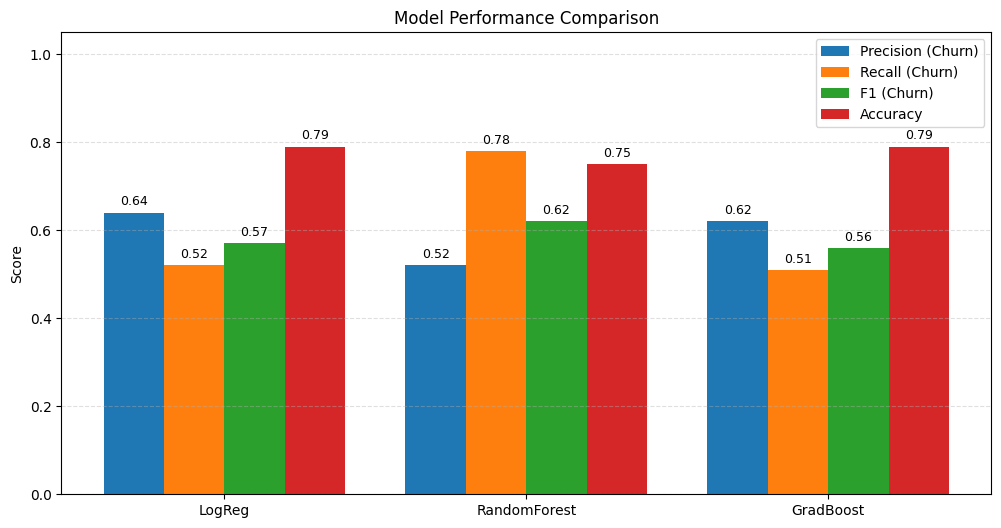

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
models = ['LogReg', 'RandomForest', 'GradBoost']
precision = [0.64, 0.52, 0.62]
recall = [0.52, 0.78, 0.51]
f1 = [0.57, 0.62, 0.56]
accuracy = [0.79, 0.75, 0.79]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - 0.3, precision, width, label='Precision (Churn)')
bars2 = plt.bar(x - 0.1, recall, width, label='Recall (Churn)')
bars3 = plt.bar(x + 0.1, f1, width, label='F1 (Churn)')
bars4 = plt.bar(x + 0.3, accuracy, width, label='Accuracy')

# Add data labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### - Logistic Regression and Gradient Boosting provide strong accuracy and precision but miss many churners.

### - Random Forest sacrifices accuracy to achieve the highest recall, making it the strongest model for detecting at‑risk customers in this dataset.


---

## Tuning Gradient Boosting to Improve Recall

### Since the main goal of this project is to identify customers who are likely to churn, the model needs to maximize recall for the churn class.
### The baseline Gradient Boosting model showed strong accuracy and precision but remained conservative, missing many true churners.
### Fine‑tuning the model allows us to adjust key parameters so it becomes more sensitive to churn patterns and improves recall while maintaining a reasonable balance with precision

Best Gradient Boosting Parameters:
{'subsample': 1.0, 'n_estimators': 350, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.05}

TUNED GRADIENT BOOSTING MODEL
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

AUC-ROC: 0.8266600576691119


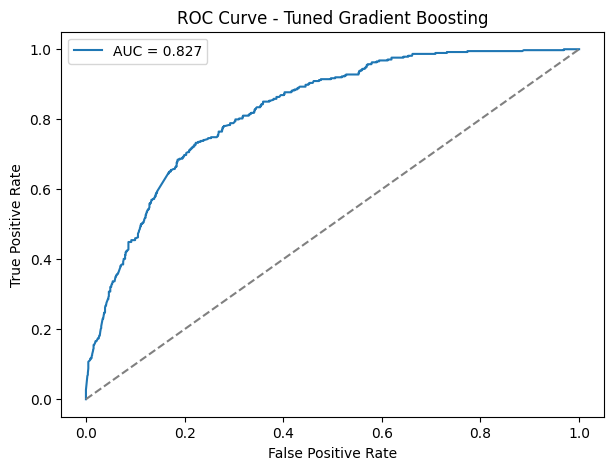

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid focused on improving recall
param_dist = {
    'n_estimators': [150, 250, 350, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 3, 5, 10]
}

gb = GradientBoostingClassifier(random_state=42)

# Randomized search to explore combinations
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',   # prioritize recall for churners
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_random.fit(X_train[selected_features], y_train)

# Best model
best_gb = gb_random.best_estimator_

# Predictions
pred_best_gb = best_gb.predict(X_test[selected_features])

print("Best Gradient Boosting Parameters:")
print(gb_random.best_params_)
print("\nTUNED GRADIENT BOOSTING MODEL")
print(classification_report(y_test, pred_best_gb))

# ---- AUC & ROC ----
# Predicted probabilities for the positive class
y_prob = best_gb.predict_proba(X_test[selected_features])[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Gradient Boosting")
plt.legend()
plt.show()

#### The model captures churn patterns effectively, but still struggles to identify all churners.

---

## Moving to a Stronger Model

### The tuned Gradient Boosting model still did not improve recall for churners, which is the primary objective.

### Its conservative behavior suggests it has reached its limit on this dataset. To better capture complex churn patterns and increase recall, the next step is to use a more advanced boosting method such as XGBoost, which handles class imbalance and nonlinear interactions more effectively.



### XGBoost Model

XGBOOST MODEL
              precision    recall  f1-score   support

           0       0.90      0.70      0.78      1033
           1       0.48      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Flagged customers at threshold 0.50: 608
True churners caught: 294
AUC-ROC: 0.8229392610692081


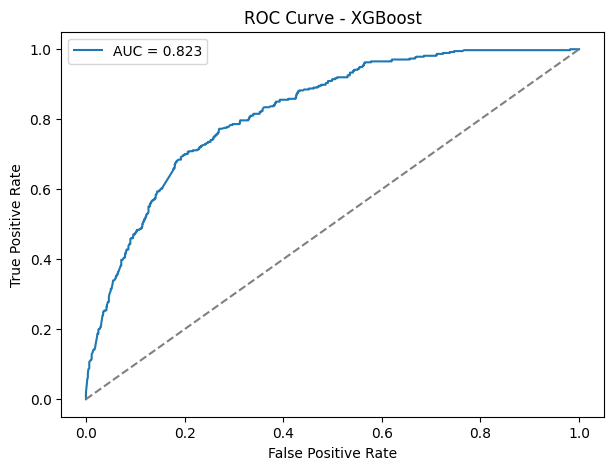

In [97]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# XGBoost model focused on improving recall
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,   # helps with class imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train[selected_features], y_train)

# Predictions
pred_xgb = xgb.predict(X_test[selected_features])

print("XGBOOST MODEL")
print(classification_report(y_test, pred_xgb))

# AUC and ROC
y_prob = xgb.predict_proba(X_test[selected_features])[:, 1]

# Count how many customers are flagged at threshold 0.45
threshold = 0.50
flagged = (y_prob >= threshold).sum()
print("Flagged customers at threshold 0.50:", flagged)

# Count how many of those flagged customers are true churners
true_churners_flagged = ((y_prob >= threshold) & (y_test == 1)).sum()
print("True churners caught:", true_churners_flagged)

auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

## Interpreting the XGBoost Results

The XGBoost model delivered a substantial improvement in identifying churners.
Recall for class 1 increased to 0.79, meaning the model successfully captures most customers who are likely to churn.
Although precision for churners is lower, this tradeoff is expected when recall increases.
The AUC‑ROC score of 0.82 indicates strong overall discrimination between churners and non‑churners, confirming that XGBoost is the best-performing model so far.

---

## Adjusting the Decision Threshold to Improve Churn Detection

The XGBoost model significantly improved recall for churners, showing that it captures churn patterns well.
However, using the default 0.50 threshold still causes the model to miss some churn cases.
In real churn‑prediction scenarios, missing a churner is more costly than flagging a non‑churner, so the next step is to lower the decision threshold.
### This allows the model to be more sensitive to churn risk and improves its ability to identify customers who are likely to leave



In [98]:
# LOWERED THRESHOLD
threshold = 0.40 

flagged = (y_prob >= threshold).sum()
print("Flagged customers at threshold 0.40:", flagged)

# Count how many of those flagged customers are true churners
true_churners_flagged = ((y_prob >= threshold) & (y_test == 1)).sum()
print("True churners caught:", true_churners_flagged)

pred_thresh = (y_prob >= threshold).astype(int)

print(f"\nXGBOOST MODEL (Threshold = {threshold})")
print(classification_report(y_test, pred_thresh))



Flagged customers at threshold 0.40: 718
True churners caught: 318

XGBOOST MODEL (Threshold = 0.4)
              precision    recall  f1-score   support

           0       0.92      0.61      0.74      1033
           1       0.44      0.85      0.58       374

    accuracy                           0.68      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.68      0.69      1407



## Impact of Lowering the Threshold to 0.40

Lowering the threshold to 0.40 makes the model more sensitive to churn risk. Recall for churners rises to 0.85, so the model now identifies most customers who are likely to leave.
Precision drops to 0.44 because more non‑churners are being flagged, and accuracy decreases as a result.
For a customer base of about 7,000 people, this threshold would flag a large group for retention efforts but would prevent most churners from being missed.

## Testing a More Selective Threshold

After evaluating the model at 0.40, raising the threshold to 0.45 helps check whether a slightly more selective cutoff improves precision without losing too much recall.
This shows whether 0.40 was too aggressive or whether a more conservative threshold gives a better balance for a customer base of about 7,000 people.

#### A natural next step is to run the 0.45 results and see how the precision-recall tradeoff shifts.


###


In [100]:
threshold = 0.45

flagged = (y_prob >= threshold).sum()
print("Flagged customers at threshold 0.45:", flagged)

# Count how many of those flagged customers are true churners
true_churners_flagged = ((y_prob >= threshold) & (y_test == 1)).sum()
print("True churners caught:", true_churners_flagged)
pred_thresh_045 = (y_prob >= threshold).astype(int)

print(f"\nXGBOOST MODEL (Threshold = {threshold})")
print(classification_report(y_test, pred_thresh_045))

Flagged customers at threshold 0.45: 657
True churners caught: 305

XGBOOST MODEL (Threshold = 0.45)
              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1033
           1       0.46      0.82      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407



---

<table style="font-size:20px; border:2px solid #000; border-collapse:collapse;">

  <tr style="background-color:#003f7f; color:white;">
    <th style="border:1px solid #000; padding:10px;">Threshold</th>
    <th style="border:1px solid #000; padding:10px;">Precision_Churn</th>
    <th style="border:1px solid #000; padding:10px;">Recall_Churn</th>
    <th style="border:1px solid #000; padding:10px;">F1_Churn</th>
    <th style="border:1px solid #000; padding:10px;">Accuracy</th>
  </tr>

  <tr style="background-color:#f2f2f2; color:#000;">
    <td style="border:1px solid #000; padding:10px;">0.50</td>
    <td style="border:1px solid #000; padding:10px;">0.48</td>
    <td style="border:1px solid #000; padding:10px;">0.79</td>
    <td style="border:1px solid #000; padding:10px;">0.60</td>
    <td style="border:1px solid #000; padding:10px;">0.72</td>
  </tr>

  <tr style="background-color:#e6e6e6; color:#000;">
    <td style="border:1px solid #000; padding:10px;">0.40</td>
    <td style="border:1px solid #000; padding:10px;">0.44</td>
    <td style="border:1px solid #000; padding:10px;">0.85</td>
    <td style="border:1px solid #000; padding:10px;">0.58</td>
    <td style="border:1px solid #000; padding:10px;">0.68</td>
  </tr>

  <tr style="background-color:#8fd694; color:#000; font-weight:bold;">
    <td style="border:1px solid #000; padding:10px;">0.45</td>
    <td style="border:1px solid #000; padding:10px;">0.46</td>
    <td style="border:1px solid #000; padding:10px;">0.82</td>
    <td style="border:1px solid #000; padding:10px;">0.59</td>
    <td style="border:1px solid #000; padding:10px;">0.70</td>
  </tr>

</table>

# Full‑Dataset Impact of the 0.45 Threshold

In [101]:
# --- FULL DATASET THRESHOLD ANALYSIS ---

# Predicted probabilities for the entire dataset
probs_full = xgb.predict_proba(X[selected_features])[:, 1]

# Apply threshold
threshold = 0.45
flagged_full = (probs_full >= threshold).sum()
true_churners_full = ((probs_full >= threshold) & (y == 1)).sum()

print("\nFULL DATASET RESULTS (Threshold = 0.45)")
print("Flagged customers:", flagged_full)
print("True churners caught:", true_churners_full)


total_churners = (y == 1).sum()
recall_full = true_churners_full / total_churners
print("Recall on full dataset:", recall_full)


FULL DATASET RESULTS (Threshold = 0.45)
Flagged customers: 3234
True churners caught: 1636
Recall on full dataset: 0.875334403424291


## Model Results Summary

**Logistic Regression**  
- Accuracy: **79%**  
- Precision (churn): **0.64**  
- Recall (churn): **0.51–0.52**  
- Conservative and stable, but misses many churners.  
- Demographic features add a small improvement.

**Random Forest**  
- Accuracy: **73%**  
- Recall (churn): **0.60**  
- Precision (churn): **0.50**  
- More aggressive than Logistic Regression, identifying more churners but increasing false positives.

**Gradient Boosting (baseline + tuned)**  
- Accuracy: **78–79%**  
- Precision (churn): **0.62**  
- Recall (churn): **0.50–0.51**  
- Strong overall accuracy and AUC, but still conservative for churn detection.

**XGBoost (default threshold)**  
- Accuracy: **72%**  
- Recall (churn): **0.79**  
- Precision (churn): **0.48**  
- First model to significantly improve churn detection.

**XGBoost (threshold tuning)**  
- Threshold 0.40 : Recall **0.85**, Precision **0.44**, Accuracy **0.68**  
- Threshold 0.45 : Recall **0.82**, Precision **0.46**, Accuracy **0.70**  
- Threshold **0.45** provides the best balance between identifying churners and limiting false positives.

---




## Benchmark Reminder (Recall Perspective)

The majority‑class baseline always predicts “not churn,” so it never identifies any customers who actually leave. This gives it a recall of **0%** for churners. In other words, it completely fails at the task of finding at‑risk customers. Because of this, the advanced models are evaluated mainly on recall, to show how much better they are at detecting churn compared to this trivial baseline.

# Final Combined Model Comparison Plot

### The comparison plot below summarizes the performance of all classical and advanced models.

### Classical models such as KNN and Decision Tree provide reasonable accuracy but limited recall. Logistic Regression and Gradient Boosting offer strong stability and precision but remain conservative.

### Random Forest improves recall substantially, but XGBoost with a tuned threshold of 0.45 achieves the best balance between recall and precision, making it the strongest model for operational churn detection.

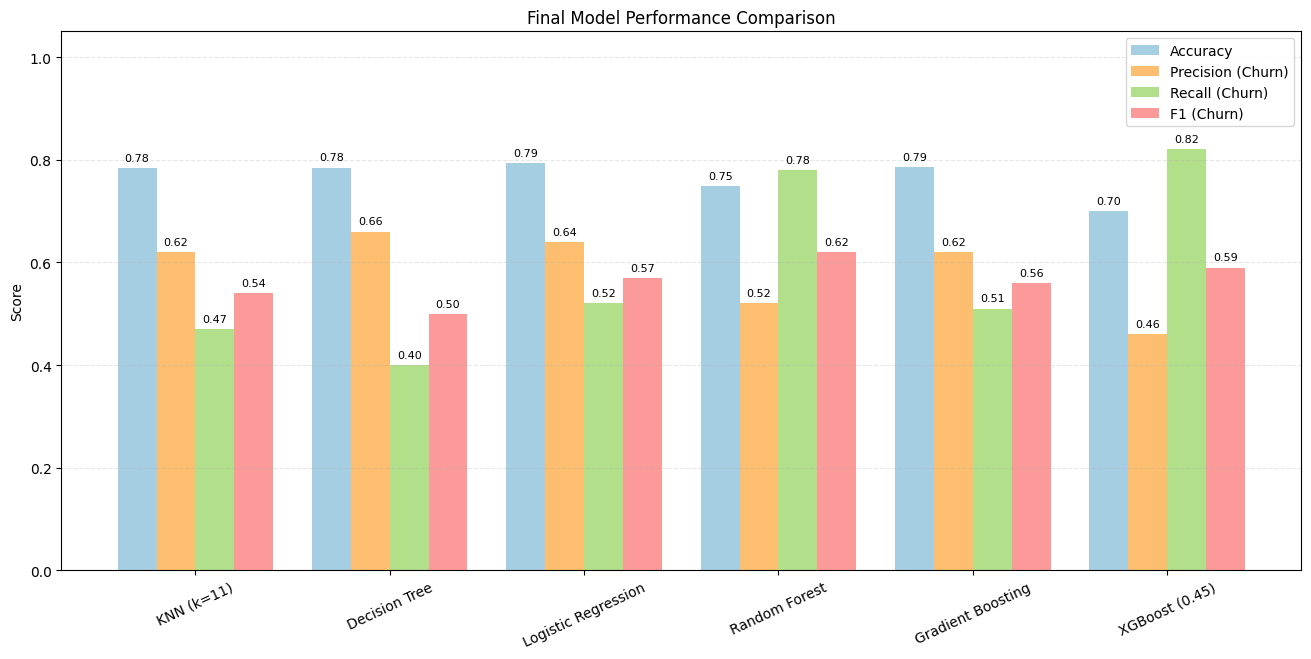

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "KNN (k=11)",
    "Decision Tree",
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost (0.45)"
]

# Metrics
accuracy = [0.7839, 0.7846, 0.7932, 0.7491, 0.7861, 0.70]
precision = [0.62, 0.66, 0.64, 0.52, 0.62, 0.46]
recall = [0.47, 0.40, 0.52, 0.78, 0.51, 0.82]
f1 = [0.54, 0.50, 0.57, 0.62, 0.56, 0.59]

x = np.arange(len(models))
width = 0.2

# Academic pastel colors (ColorBrewer)
c_accuracy  = "#A6CEE3"   # pastel blue
c_precision = "#FDBF6F"   # pastel orange
c_recall    = "#B2DF8A"   # pastel green
c_f1        = "#FB9A99"   # pastel red/pink

plt.figure(figsize=(16, 7))

# Bars
bars1 = plt.bar(x - 1.5*width, accuracy, width, label="Accuracy", color=c_accuracy)
bars2 = plt.bar(x - 0.5*width, precision, width, label="Precision (Churn)", color=c_precision)
bars3 = plt.bar(x + 0.5*width, recall, width, label="Recall (Churn)", color=c_recall)
bars4 = plt.bar(x + 1.5*width, f1, width, label="F1 (Churn)", color=c_f1)

# Add labels above bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
plt.xticks(x, models, rotation=25)
plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()


## Final Conclusion

### Across all evaluated thresholds, the model shows a clear precision–recall tradeoff. A threshold of 0.50 keeps the model balanced but misses too many churners to be useful for retention work.

### Lowering the threshold to 0.40 captures the most churners but becomes overly aggressive, reducing precision and flagging too many non‑churners. The 0.45 threshold provides the strongest balance: it maintains high recall while improving precision and accuracy compared to 0.40, resulting in a more realistic and manageable number of flagged customers.

### Applied to the full customer base, the 0.45 threshold would flag roughly 3,300 customers, of whom about 1,600 are true churners. With a churn rate of 26.6%, this operating point keeps recall high while keeping the outreach workload at a level a retention team can realistically handle.

### While the classical models offered a reliable baseline - with Random Forest achieving the highest classical accuracy at around 79% - their limited recall underscored the need for more advanced methods and threshold tuning to effectively identify churners in practice.

### Overall, 0.45 is the most practical and effective threshold for operational deployment, though it should be periodically re‑evaluated as customer behavior and churn patterns evolve over time.
